# UK Police
## 1. Introduction
This notebook aims to conduct a large-scale data analysis of the **Stop and Search** records provided by the UK Police through their open data portal ([data.police.uk](https://data.police.uk/)). 

Stop and Search is a power granted to police officers to search individuals if they have "reasonable grounds" to suspect the person is carrying illegal items (drugs, weapons, stolen property). However, this practice has historically been a point of contention regarding civil liberties and systemic discrimination.

## 2. Preliminary Exploratory Data Analysis (EDA)
First of all, we need to understand the general landscape of the data: the volume of searches, what the police are looking for, and who they are searching.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
spark = SparkSession \
    .builder \
    .master("local[*]") \
    .appName("UK Police") \
    .getOrCreate()

sc = spark.sparkContext

sc._jvm.org.apache.log4j.Logger.getLogger("org.apache.spark.scheduler.TaskSetManager").setLevel(
    spark.sparkContext._jvm.org.apache.log4j.Level.ERROR
)

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/10 22:50:23 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [2]:
file_path = "/home/alumno/reposirotio/Grupo1/stop_search_data.parquet"
df = spark.read.parquet(file_path,inferSchema=True).cache()

In [3]:
# Count total records
total_records = df.count()
print(f"Total number of search records: {total_records:,}")

# Show schema to understand available features
df.printSchema()

# Display a sample of the data
df.limit(5).toPandas()

Total number of search records: 1,451,297
root
 |-- age_range: string (nullable = true)
 |-- outcome: string (nullable = true)
 |-- involved_person: boolean (nullable = true)
 |-- self_defined_ethnicity: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- legislation: string (nullable = true)
 |-- outcome_linked_to_object_of_search: boolean (nullable = true)
 |-- datetime: string (nullable = true)
 |-- removal_of_more_than_outer_clothing: boolean (nullable = true)
 |-- operation: boolean (nullable = true)
 |-- officer_defined_ethnicity: string (nullable = true)
 |-- type: string (nullable = true)
 |-- operation_name: integer (nullable = true)
 |-- object_of_search: string (nullable = true)
 |-- date: string (nullable = true)
 |-- force_id: string (nullable = true)
 |-- outcome_object.id: string (nullable = true)
 |-- outcome_object.name: string (nullable = true)
 |-- location.latitude: string (nullable = true)
 |-- location.street.id: double (nullable = true)
 |-- locat

,age_range,outcome,involved_person,self_defined_ethnicity,gender,legislation,outcome_linked_to_object_of_search,datetime,removal_of_more_than_outer_clothing,operation,...,object_of_search,date,force_id,outcome_object.id,outcome_object.name,location.latitude,location.street.id,location.street.name,location.longitude,location
0,10-17,A no further action disposal,True,White - English/Welsh/Scottish/Northern Irish/...,Male,Misuse of Drugs Act 1971 (section 23),None,2025-10-16T21:59:57+00:00,False,None,...,Controlled drugs,2025-10,avon-and-somerset,bu-no-further-action,A no further action disposal,51.495086,2278369.0,On or near Wellesley Mews,-2.599790,NaN
1,18-24,,True,None,Male,None,None,2025-10-28T16:06:01+00:00,None,None,...,None,2025-10,avon-and-somerset,,,None,NaN,None,None,NaN
2,None,A no further action disposal,True,Other ethnic group - Not stated,None,Firearms Act 1968 (section 47),None,2025-10-21T22:35:59+00:00,False,None,...,Firearms,2025-10,avon-and-somerset,bu-no-further-action,A no further action disposal,51.458559,2278955.0,On or near The Horsefair,-2.589740,NaN
3,10-17,Arrest,True,Asian/Asian British - Pakistani,Male,Police and Criminal Evidence Act 1984 (section 1),False,2025-10-23T15:36:34+00:00,False,None,...,Offensive weapons,2025-10,avon-and-somerset,bu-arrest,Arrest,51.452650,2279220.0,On or near Water Lane,-2.586598,NaN
4,10-17,A no further action disposal,True,White - English/Welsh/Scottish/Northern Irish/...,Male,Police and Criminal Evidence Act 1984 (section 1),None,2025-10-07T19:53:17+00:00,False,None,...,Offensive weapons,2025-10,avon-and-somerset,bu-no-further-action,A no further action disposal,51.443759,2278612.0,On or near Supermarket,-2.595117,NaN


### 2.1 Data Dictionary

The following table describes the features available in the UK Police Stop and Search dataset, it has been copy from UK Police Api website:

| Field Name | Description |
| :--- | :--- |
| **type** | Whether this was a 'Person search', a 'Vehicle search', or a 'Person and Vehicle search'. |
| **involved_person** | Whether a person was searched in this incident (derived from type; true if anything but 'Vehicle search'). |
| **datetime** | When the stop and search took place. *Note: some forces only provide dates, so midnight values may be overrepresented.* |
| **operation** | Boolean indicating whether this stop and search was part of a specific policing operation. |
| **operation_name** | The name of the operation this stop and search was part of (if applicable). |
| **location** | Approximate location of the incident (JSON/Structure). (latitude,longitude, street) |
| **latitude** | Latitude coordinate of the incident. |
| **longitude** | Longitude coordinate of the incident. |
| **street** | The approximate street-level location of the incident. (id, name)|
| **id** | Unique identifier for the location. |
| **name** | Human-readable summary of the location. |
| **gender** | Human-readable gender of the person stopped (if provided). |
| **age_range** | The age range of the person stopped at the time the stop occurred. |
| **self_defined_ethnicity** | The ethnicity of the person stopped, as defined by themselves. |
| **officer_defined_ethnicity** | The ethnicity of the person stopped, as categorized by the police officer. |
| **legislation** | The specific legal power used to carry out the stop and search (e.g., Police and Criminal Evidence Act 1984). |
| **object_of_search** | The specific reason/item the officer was looking for (e.g., Drugs, Weapons). |
| **outcome** | The outcome of the stop. `false` if nothing was found, or an empty string if not provided. |
| **outcome_linked_to_object_of_search** | Boolean indicating if the outcome was related to the reason the search was conducted (e.g., searched for drugs, found drugs). |
| **removal_of_more_than_outer_clothing** | Boolean indicating if a more thorough search (beyond outer clothing) was performed. |


### 2.2 Data analysis
#### 2.2.1 Ethnicities biases  
One of our main objectives in this study is to observe whether there are racial, gender or any other types of bias, so in the following cells we will try to observe any kind of existence around these concepts. 

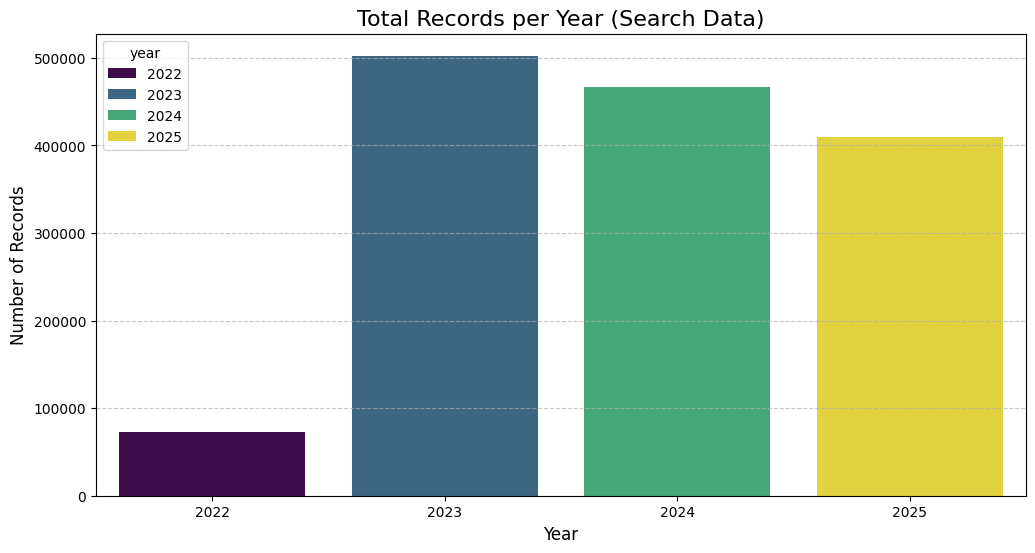

In [4]:
df_processed = df.withColumn("year", F.year(F.to_date("date").astype("string")))

# 2. Filter out nulls (if any) and group by year
yearly_counts = (df_processed
                 .filter(F.col("year").isNotNull())
                 .groupBy("year")
                 .count()
                 .orderBy("year"))

# 3. Convert the small aggregated result to Pandas for plotting
pdf = yearly_counts.toPandas()

plt.figure(figsize=(12, 6))
sns.barplot(
    data=pdf, 
    x="year",  
    y="count", 
    palette="viridis", 
    hue="year", 
    legend=True
)
# Add labels and title
plt.title('Total Records per Year (Search Data)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Records', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

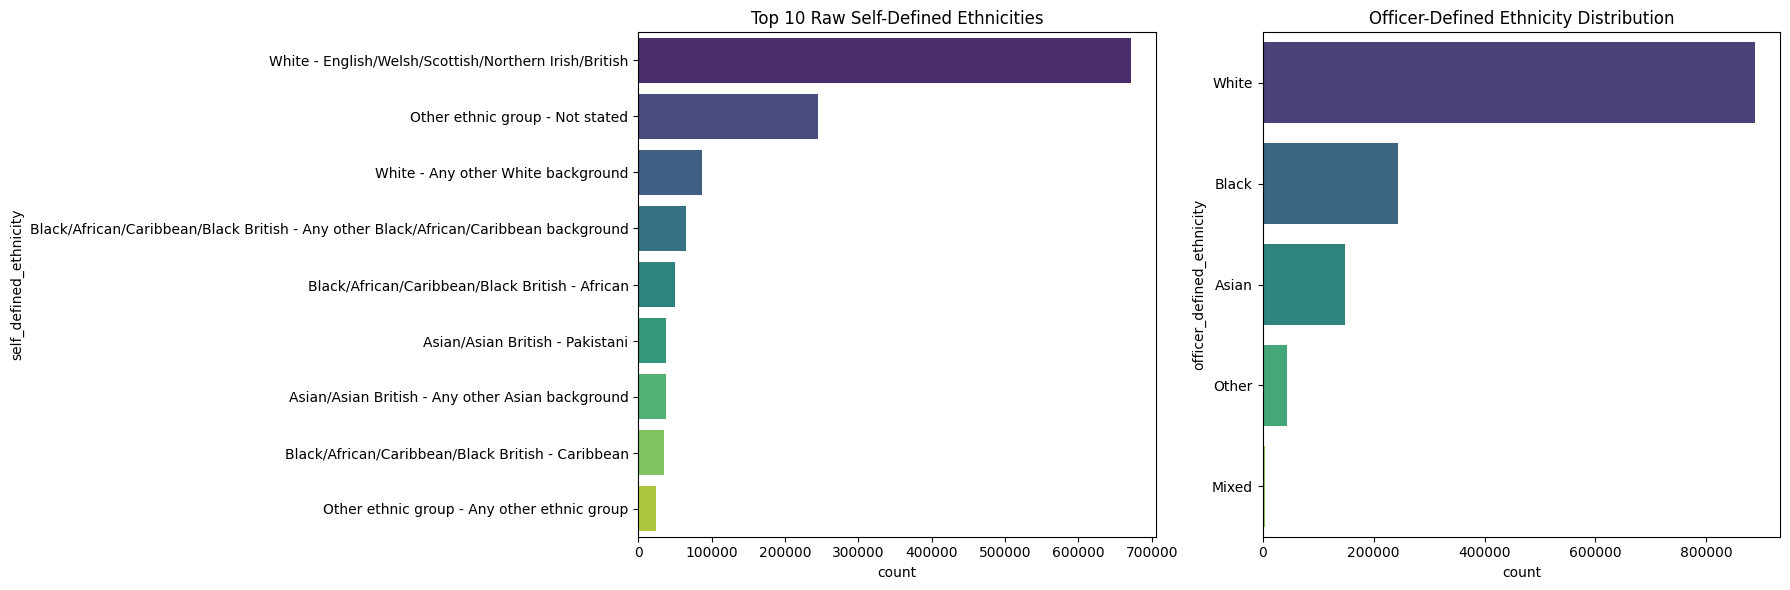

In [5]:
self_eth_raw = df.groupBy("self_defined_ethnicity").count().orderBy("count", ascending=False).limit(10).toPandas()
off_eth_raw = df.groupBy("officer_defined_ethnicity").count().orderBy("count", ascending=False).toPandas()

fig, ax = plt.subplots(1, 2, figsize=(18, 6))

sns.barplot(
    data=self_eth_raw, 
    x="count", 
    y="self_defined_ethnicity", 
    ax=ax[0], 
    palette="viridis", 
    hue="self_defined_ethnicity", 
    legend=False
)
ax[0].set_title("Top 10 Raw Self-Defined Ethnicities")

sns.barplot(
    data=off_eth_raw, 
    x="count", 
    y="officer_defined_ethnicity", 
    ax=ax[1], 
    palette="viridis", 
    hue="officer_defined_ethnicity", 
    legend=False
)
ax[1].set_title("Officer-Defined Ethnicity Distribution")

plt.tight_layout()
plt.show()

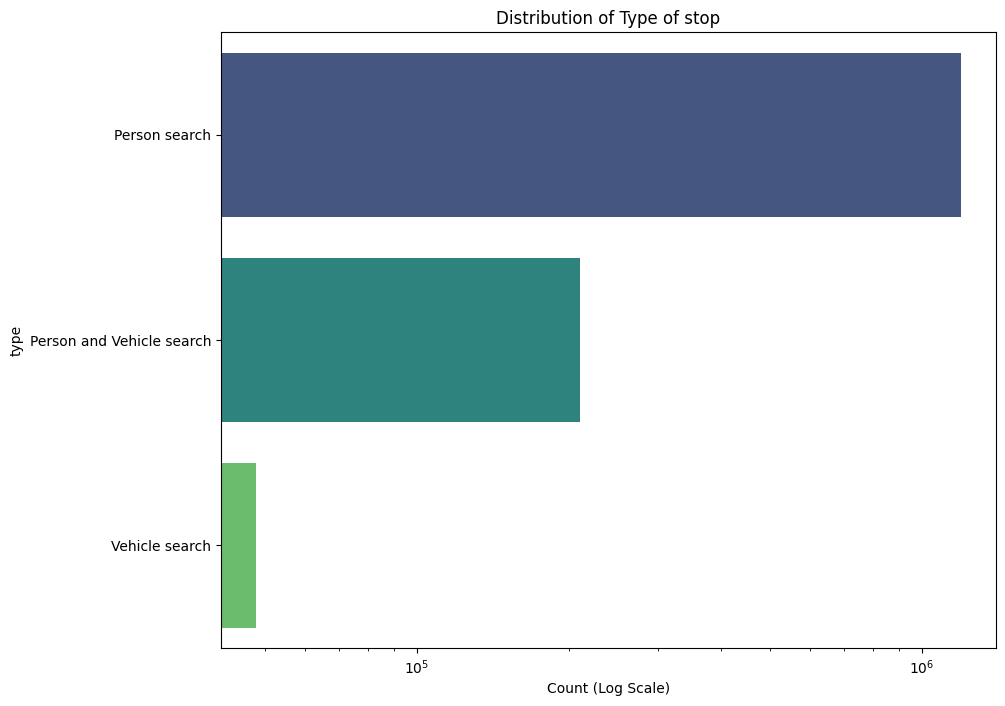

Sample of raw outcome strings:
['Person search', 'Person and Vehicle search', 'Vehicle search']


In [6]:
raw_outcomes = df.groupBy("type").count().orderBy("count", ascending=False).toPandas()

plt.figure(figsize=(10, 8))
sns.barplot(data=raw_outcomes, 
            x="count",
            y="type",
            palette="viridis",
            hue="type",
            legend=False)
plt.title("Distribution of Type of stop")
plt.xscale("log") # Using log scale because 'Nothing found' usually dwarfs others
plt.xlabel("Count (Log Scale)")
plt.show()

print("Sample of raw outcome strings:")
print(raw_outcomes['type'].head(15).tolist())

In [7]:
raw_outcomes = df.groupBy("involved_person").count().orderBy("count", ascending=False).toPandas()

raw_outcomes.head()

,involved_person,count
0,True,1403329
1,False,47968


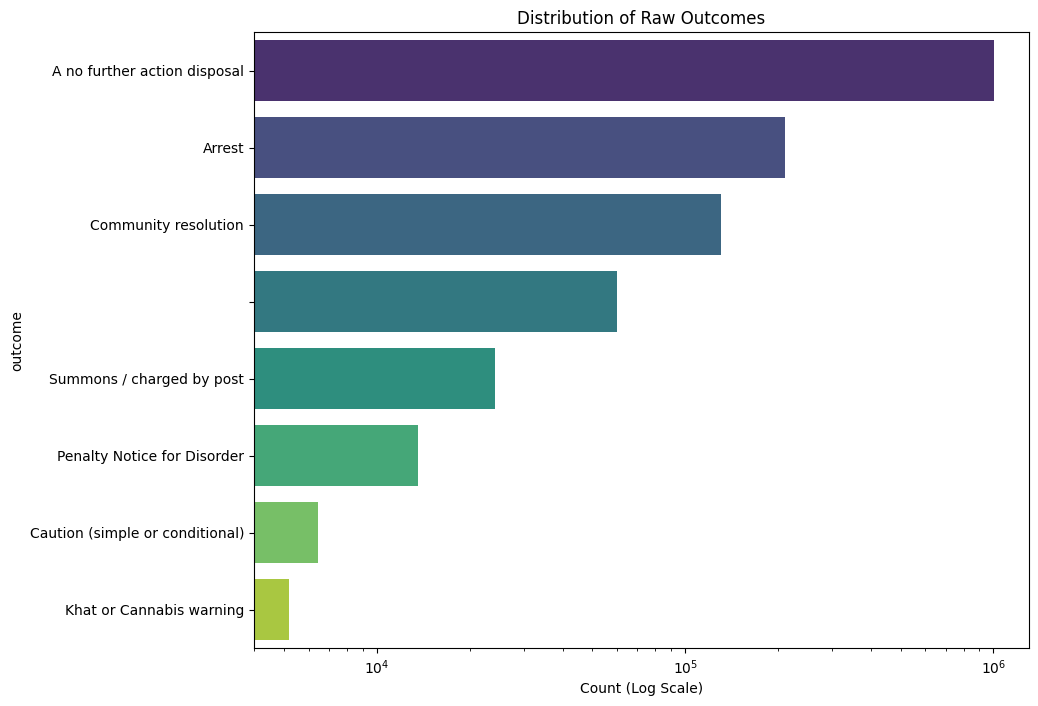

Sample of raw outcome strings:
['A no further action disposal', 'Arrest', 'Community resolution', '', 'Summons / charged by post', 'Penalty Notice for Disorder', 'Caution (simple or conditional)', 'Khat or Cannabis warning']


In [8]:
raw_outcomes = df.groupBy("outcome").count().orderBy("count", ascending=False).toPandas()

plt.figure(figsize=(10, 8))
sns.barplot(data=raw_outcomes, 
            x="count",
            y="outcome",
            palette="viridis",
            hue="outcome",
            legend=False)
plt.title("Distribution of Raw Outcomes")
plt.xscale("log") # Using log scale because 'Nothing found' usually dwarfs others
plt.xlabel("Count (Log Scale)")
plt.show()

print("Sample of raw outcome strings:")
print(raw_outcomes['outcome'].head(15).tolist())

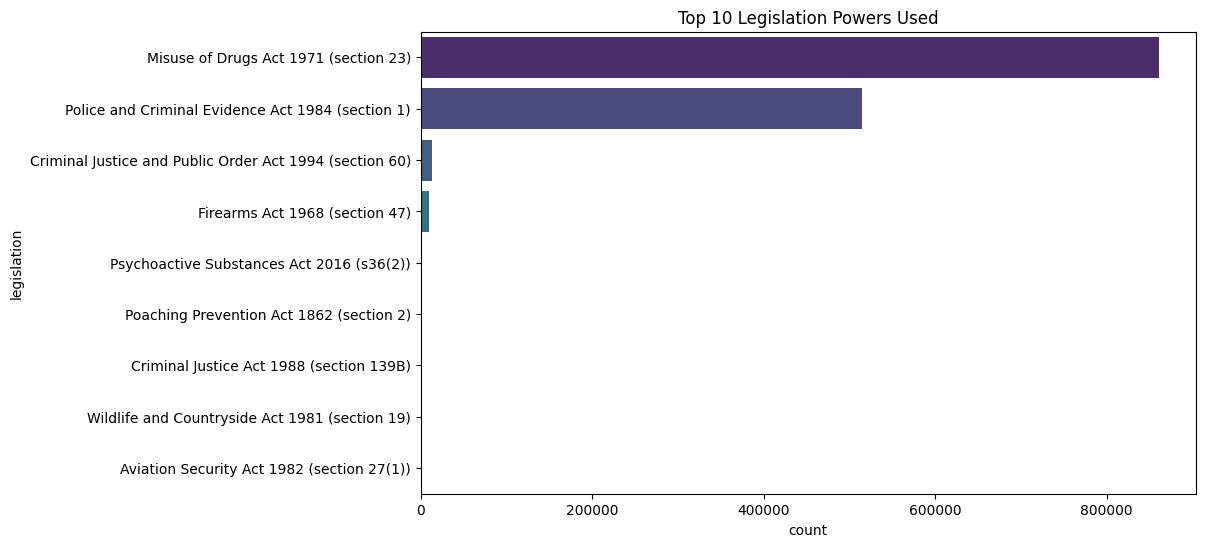

In [9]:
legislation_dist = df.groupBy("legislation").count().orderBy("count", ascending=False).limit(10).toPandas()

plt.figure(figsize=(10, 6))

sns.barplot(
    data=legislation_dist, 
    x="count", 
    y="legislation", 
    palette="viridis", 
    hue="legislation", 
    legend=False
)
plt.title("Top 10 Legislation Powers Used")
plt.show()

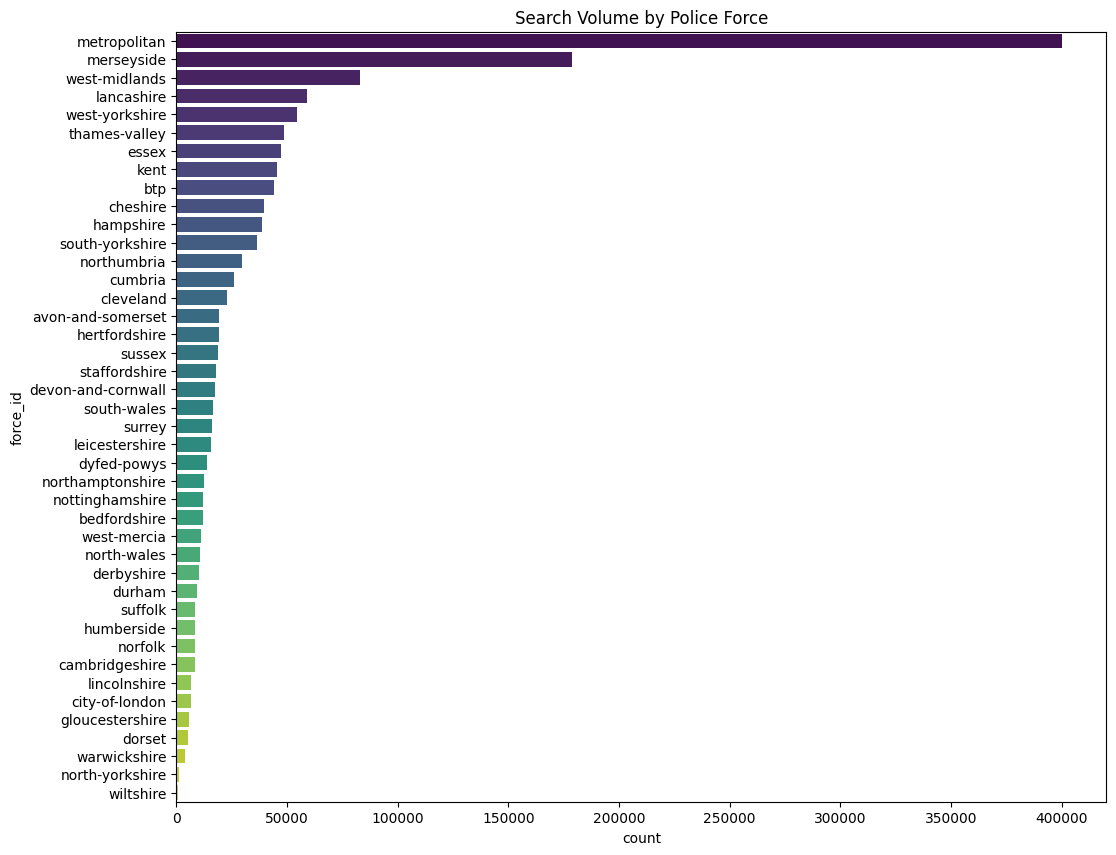

In [10]:
# Number of records per Police Force
force_dist = df.groupBy("force_id").count().orderBy("count", ascending=False).toPandas()

plt.figure(figsize=(12, 10))
sns.barplot(data=force_dist,
            x="count",
            y="force_id",
            palette="viridis",
            hue="force_id", 
            legend=False)
plt.title("Search Volume by Police Force")
plt.show()

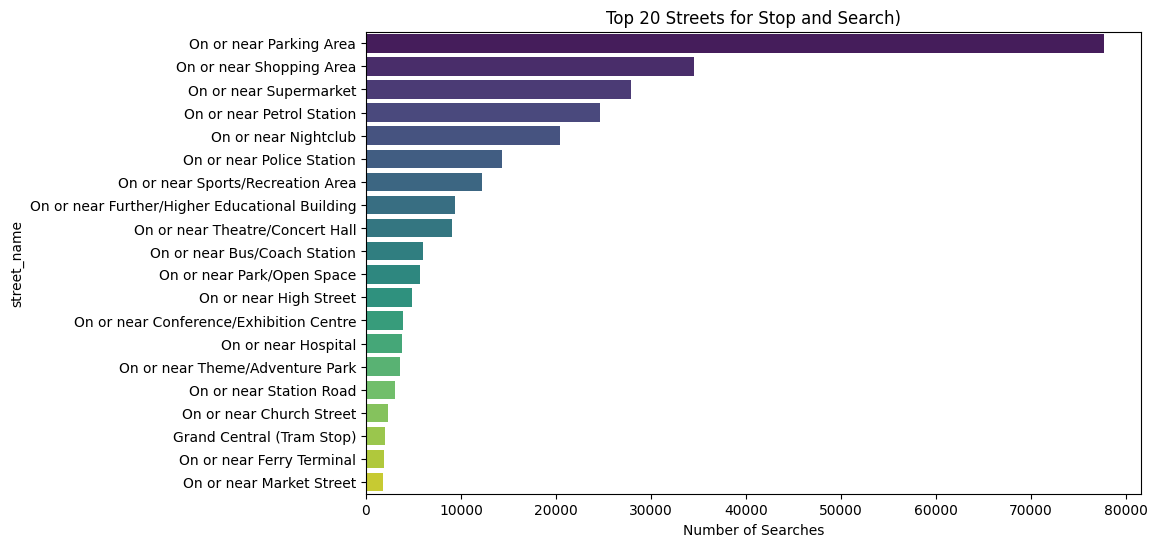

In [11]:
# Most frequent streets for stops
top_streets = df.filter(F.col("`location.street.name`").isNotNull()) \
    .groupBy("`location.street.name`") \
    .count() \
    .orderBy("count", ascending=False) \
    .select(F.col("`location.street.name`").alias("street_name"), 
            F.col("count")
    ).limit(20).toPandas()
plt.figure(figsize=(10, 6))
sns.barplot(data=top_streets,
            x="count",
            y="street_name",
            palette="viridis",
            hue="street_name",
            legend=False
           )
plt.title("Top 20 Streets for Stop and Search)")
plt.xlabel("Number of Searches")
plt.show()

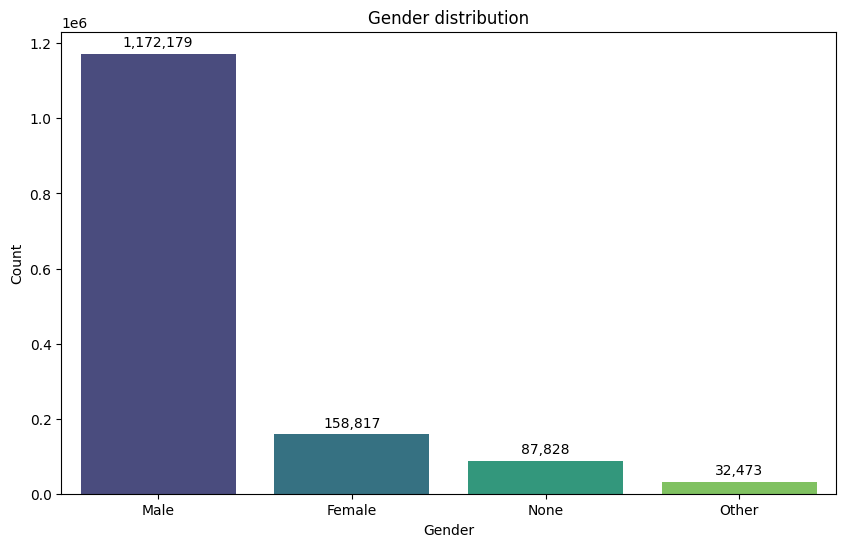

In [12]:
count_data = df.groupBy("gender").count().sort(F.col("count"),ascending=False).toPandas()
count_data['gender'] = count_data['gender'].fillna('None')


plt.figure(figsize=(10, 6))
ax = sns.barplot(
    data=count_data, 
    x="gender", 
    y="count", 
    hue="gender",   
    palette="viridis", 
    legend=False
)

for container in ax.containers:
    ax.bar_label(container, fmt='{:,.0f}', padding=3)

plt.title("Gender distribution")
plt.ylabel("Count")
plt.xlabel("Gender")
plt.show()

Due to the small quantity of non Male or Female gender for the first visualization of the relation between ethnicity and gender

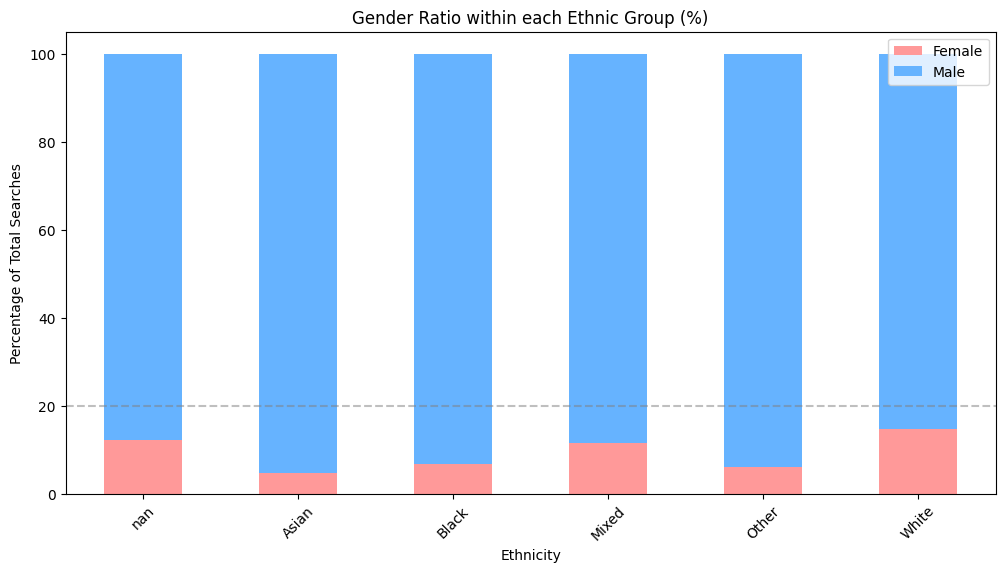

In [13]:
gender_eth_stats = df.filter(F.col("gender").isin("Male", "Female")) \
    .groupBy("officer_defined_ethnicity", "gender") \
    .count() \
    .orderBy("officer_defined_ethnicity") \
    .toPandas()

pivot_df = gender_eth_stats.pivot(index='officer_defined_ethnicity', columns='gender', values='count')
pivot_df_perc = pivot_df.div(pivot_df.sum(axis=1), axis=0) * 100

pivot_df_perc.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#ff9999','#66b3ff'])
plt.title("Gender Ratio within each Ethnic Group (%)")
plt.ylabel("Percentage of Total Searches")
plt.xlabel("Ethnicity")
plt.axhline(20, color='gray', linestyle='--', alpha=0.5)
plt.legend(loc='upper right')
plt.xticks(rotation=45)
plt.show()

## 3. Data preprocessing

In [14]:
df = df.filter(F.col("involved_person")==True)


In [15]:
df = df\
    .withColumn("year", F.year(F.col("datetime")))\
    .withColumn("dayofyear", F.dayofyear(F.col("datetime")))\
    .withColumn("dayofweek", F.dayofweek(F.col("datetime")))\
    .withColumn("hour", F.hour(F.col("datetime")))\
    .withColumn("month", F.month(F.col("datetime")))
df.select('dayofyear', 'dayofweek','hour', 'month','year', 'datetime').limit(5).toPandas()

,dayofyear,dayofweek,hour,month,year,datetime
0,289,5,23,10,2025,2025-10-16T21:59:57+00:00
1,301,3,17,10,2025,2025-10-28T16:06:01+00:00
2,294,3,0,10,2025,2025-10-21T22:35:59+00:00
3,296,5,17,10,2025,2025-10-23T15:36:34+00:00
4,280,3,21,10,2025,2025-10-07T19:53:17+00:00


To keep our model efficient and focused on the core problem of systemic bias, we are dropping several columns that are either redundant, too specific, or filled with missing information. 

First, we are removing **`datetime`** because we have already extracted its useful parts (like the hour and the month), so the raw timestamp is no longer needed. We are also discarding **`operation`** and **`operation_name`** because they are usually empty or refer to very specific, one-time events that don't help us find general patterns in police behavior. 

Regarding the outcomes, we are dropping **`outcome_linked_to_object_of_search`** and **`outcome_object`** to simplify our target variable; since we are focusing strictly on whether an arrest happened or not, these extra details just add noise to the model. Finally, we are excluding **`self_defined_ethnicity`** in favor of the officer-defined version. We do this because the self-defined list has too many tiny sub-categories that make the Decision Tree messy, and more importantly, because studying the **officer's perception** is the key to identifying the potential prejudices that lead to a search in the first place. 

By cleaning the dataset this way, we ensure that Spark runs much faster and the Decision Tree stays focused on the variables that actually matter for our bias audit.

In [16]:
cols_to_drop = [
    "operation",
    "operation_name",
    "outcome_linked_to_object_of_search",
    "outcome_object",
    "self_defined_ethnicity",
]
df_filtered = df.drop(*cols_to_drop)

df_filtered = df_filtered.select(    
    F.col("age_range").alias("age"),
    F.col("outcome").alias("outcome"),
    F.col("involved_person").alias("is_person"),
    F.col("gender").alias("gender"),
    F.col("legislation").alias("law"),
    F.col("year"),
    F.to_timestamp("datetime").alias("timestamp"),
    F.col("dayofyear"),
    F.col("dayofweek"),
    F.col("hour"),
    F.col("month"),
    F.col("removal_of_more_than_outer_clothing").alias("strip_search"),
    F.col("officer_defined_ethnicity").alias("ethnicity"),
    F.col("type").alias("search_type"),
    F.col("object_of_search").alias("reason"),
    F.col("force_id").alias("police_force"),
    F.col("`location.latitude`").alias("latitude"),
    F.col("`location.longitude`").alias("longitude"),
    F.col("`location.street.id`").alias("street_id"),
    F.col("`location.street.name`").alias("street_name")
)

In [17]:
# List of outcomes that represent a "successful" search (some form of legal trouble)
positive_outcomes = ['Arrest','Community resolution', 'Summons / charged by post', 'Penalty Notice for Disorder', 'Caution (simple or conditional)', 'Khat or Cannabis warning']
# Create the new binary target variable
df_filtered = df_filtered.withColumn("legal_action_taken", 
    F.when(F.col("outcome").isin(positive_outcomes), 1).otherwise(0)
)
# Check the distribution
df_filtered.groupBy("legal_action_taken").count().toPandas()

,legal_action_taken,count
0,1,378213
1,0,1025116


In [18]:

print("Geographical Data Completeness:")
df_filtered.select(
    F.count(F.when(F.col("latitude").isNotNull(), 1)).alias("With_coords"),
    F.count(F.when(F.col("latitude").isNull(), 1)).alias("Without_coords"),
    F.count(F.when(F.col("police_force").isNull(), 1)).alias("Without Police force"),
).toPandas()

Geographical Data Completeness:


,With_coords,Without_coords,Without Police force
0,1253991,149338,0


We decided to use the **`police_force`** as our primary geographical feature instead of coordinates or street names because it is much more reliable and practical for a Big Data study. Using exact latitude and longitude or thousands of different street names is problematic because that data is often incomplete or missing, and there are so many unique streets that the model would just get overwhelmed and start _"memorizing"_ specific corners instead of finding real patterns. 

The main idea is: instead of trying to track every single floor tile a person steps on, it’s much more useful to know which building they are in and what the rules are there. By focusing on the police force, we can see the institutional "vibe" and specific policies of a whole department like comparing the Metropolitan Police to Greater Manchester making our bias audit much clearer, more scalable, and way more professional.

In [19]:
cols_to_drop = [
    "is_person",
    "strip_search",
    "latitude",
    "longitude",
    "street_id",
    "street_name",
    'outcome'
]
df_final = df_filtered.drop(*cols_to_drop)
df_final.printSchema()

root
 |-- age: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- law: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- dayofyear: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- ethnicity: string (nullable = true)
 |-- search_type: string (nullable = true)
 |-- reason: string (nullable = true)
 |-- police_force: string (nullable = true)
 |-- legal_action_taken: integer (nullable = false)



In [20]:
# Final Null check to prevent VectorAssembler crashes
categorical_cols = ["age", "gender", "law", "ethnicity", "search_type", "reason", "police_force"]
df_final = df_final.fillna("Unknown", subset=categorical_cols)
df_final = df_final.fillna(0, subset=["hour", "month", "dayofweek", "dayofyear" ])


df_final.write.mode("overwrite").parquet("data/processed_data.parquet")
df_final.printSchema()

[Stage 88:===========================================>              (3 + 1) / 4]

root
 |-- age: string (nullable = false)
 |-- gender: string (nullable = false)
 |-- law: string (nullable = false)
 |-- year: integer (nullable = true)
 |-- timestamp: timestamp (nullable = true)
 |-- dayofyear: integer (nullable = true)
 |-- dayofweek: integer (nullable = true)
 |-- hour: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- ethnicity: string (nullable = false)
 |-- search_type: string (nullable = false)
 |-- reason: string (nullable = false)
 |-- police_force: string (nullable = false)
 |-- legal_action_taken: integer (nullable = false)



In [21]:
# Define the training ratio per year
train_ratio = 0.8

# Create a dictionary with the ratio for each year
years = df_final.select("year").distinct().collect()
fractions = {row.year: train_ratio for row in years}

# Stratified sampling
train_df = df_final.sampleBy("year", fractions, seed=42)

# The test set consists of records that are NOT in the train set
test_df = df_final.join(train_df, on=df_final.columns, how="left_anti")

# Verify distribution
print("=== TRAINING SET ===")
train_df.groupBy("year").count().orderBy("year").show()
print(f"Total: {train_df.count():,}")

print("\n=== TEST SET ===")
test_df.groupBy("year").count().orderBy("year").show()
print(f"Total: {test_df.count():,}")

=== TRAINING SET ===


+----+------+
|year| count|
+----+------+
|2022| 56635|
|2023|388901|
|2024|360924|
|2025|316156|
+----+------+



Total: 1,122,616

=== TEST SET ===


+----+-----+
|year|count|
+----+-----+
|2022|12661|
|2023|87114|
|2024|81323|
|2025|71148|
+----+-----+



[Stage 111:==================================>                      (3 + 2) / 5]

Total: 252,246


## 4. Pipeline for ML solving
### 4.1 Cross validation time series

In [22]:
from multiprocessing.pool import ThreadPool
from pyspark import keyword_only
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.classification import DecisionTreeClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator
from pyspark.ml import Pipeline
from pyspark.ml.param import Params, Param, TypeConverters

class tsCrossValidator(CrossValidator):
    """
    Custom validator for time-series cross-validation.

    This class extends the functionality of PySpark's CrossValidator to support
    walk-forward time-series cross-validation. It splits the dataset into
    consecutive periods with each fold using data from the past as training
    and the most recent period as validation.

    In particular, it overrides the _kFold method (which is used in the fit method)
    """
    datetimeCol = Param(
        Params._dummy(), 
        "datetimeCol", 
        "Column name for splitting the data",
        typeConverter=TypeConverters.toString)
    
    timeSplit = Param(
        Params._dummy(), 
        "timeSplit", 
        "Length of time to leave in validation set. Should be some sort of timedelta or relativedelta")
    
    gap = Param(
        Params._dummy(), 
        "gap", 
        "Length of time to leave bas gap between train and validation")
    
    disableExpandingWindow = Param(
        Params._dummy(),
        "disableExpandingWindow",
        "Boolean for disabling expanding window folds and taking rolling windows instead.",
        typeConverter=TypeConverters.toBoolean)

    @keyword_only
    def __init__(self, estimator=None, estimatorParamMaps=None, evaluator=None,
                 numFolds=3, datetimeCol = 'date', timeSplit=None, 
                 gap=None, disableExpandingWindow=False, parallelism=1, collectSubModels=False):

        super(tsCrossValidator, self).__init__(
            estimator=estimator, 
            estimatorParamMaps=estimatorParamMaps, 
            evaluator=evaluator, 
            numFolds=numFolds,
            parallelism=parallelism, 
            collectSubModels=collectSubModels
        )
       
        self._setDefault(gap=None, datetimeCol='date', timeSplit=None, disableExpandingWindow=False)

        # Explicitly set the provided values
        self._set(gap=gap, datetimeCol=datetimeCol, timeSplit=timeSplit, disableExpandingWindow=disableExpandingWindow)

        kwargs = self._input_kwargs
        self._set(**kwargs)
    
    def getDatetimeCol(self):
        return self.getOrDefault(self.datetimeCol)
    
    def setDatetimeCol(self, datetimeCol):
        return self._set(datetimeCol=datetimeCol)
    
    def getTimeSplit(self):
        return self.getOrDefault(self.timeSplit)
    
    def setTimeSplit(self, timeSplit):
        return self._set(timeSplit=timeSplit)
    
    def getDisableExpandingWindow(self):
        return self.getOrDefault(self.disableExpandingWindow)
    
    def setDisableExpandingWindow(self, disableExpandingWindow):
        return self._set(disableExpandingWindow=disableExpandingWindow)
    
    def getGap(self):
        return self.getOrDefault(self.gap)

    def setGap(self, gap):
        return self._set(gap=gap)

    def _kFold(self, dataset):
        nFolds = self.getOrDefault(self.numFolds)
        datetimeCol = self.getOrDefault(self.datetimeCol)
        timeSplit = self.getOrDefault(self.timeSplit)
        gap = self.getOrDefault(self.gap)
        disableExpandingWindow = self.getOrDefault(self.disableExpandingWindow)

        datasets = []
        endDate = dataset.agg({datetimeCol : 'max'}).collect()[0][0]
        trainLB = dataset.agg({datetimeCol: 'min'}).collect()[0][0]
        for i in reversed(range(nFolds)):
            validateUB = endDate - i * timeSplit
            validateLB = endDate - (i + 1) * timeSplit
            trainUB = validateLB - gap if gap is not None else validateLB

            val_condition = (dataset[datetimeCol] > validateLB) & (dataset[datetimeCol] <= validateUB)
            train_condition = (dataset[datetimeCol] <= trainUB) & (dataset[datetimeCol] >= trainLB)

            validation = dataset.filter(val_condition)
            train = dataset.filter(train_condition)

            datasets.append((train, validation))

            if disableExpandingWindow:
                trainLB += timeSplit
        
        return datasets

### 4.2 Cross Validator with base dataset

In [23]:
from dateutil.relativedelta import relativedelta
import time

# Verify final dataset before pipeline
print(f"Final dataset count before pipeline: {df_final.count()}")
assert df_final.count() > 0, "Dataset is empty before pipeline!"

# 1. String Indexers
indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep") 
    for col in categorical_cols
]

# 2. Vector Assembler
numeric_cols = [ "hour", "month", "dayofweek", "dayofyear"]
feature_cols = [f"{col}_idx" for col in categorical_cols] + numeric_cols
assembler = VectorAssembler(
    inputCols=feature_cols, 
    outputCol="features",
    handleInvalid="keep"
)

# 3. Decision Tree Estimator
dt = DecisionTreeClassifier(
    labelCol="legal_action_taken", 
    featuresCol="features", 
    maxDepth=5, 
    maxBins=64, 
    seed=42
)

# 4. Construct the Pipeline
pipeline = Pipeline(stages=indexers + [assembler, dt])

# 5. Evaluator
evaluator = BinaryClassificationEvaluator(
    rawPredictionCol='rawPrediction',  # Changed from 'prediction'
    labelCol='legal_action_taken',
    metricName="areaUnderPR"
)

# 6. Parameter Grid
paramGrid = (ParamGridBuilder() 
    .addGrid(dt.maxDepth, [5, 10, ]) \
    .addGrid(dt.minInstancesPerNode, [5, 10]) \
    .addGrid(dt.maxBins, [ 64, 128]) \
    .addGrid(dt.impurity, ['gini', 'entropy']) \
    .build()
    )

# 7. Time Series Cross Validator
ts_cv = tsCrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=6,
    datetimeCol='timestamp',
    timeSplit=relativedelta(months=3),
    gap=None,
    disableExpandingWindow=False,
    parallelism=2
)

# 8. Fit with error handling
try:
    print("Starting Pipeline Training with Temporal Cross-Validation...")
    start_time = time.time()
    
    # This will call your custom _kFold logic internally
    cv_model = ts_cv.fit(train_df)
    
    total_time = time.time() - start_time
    print(f"Pipeline fitting complete. Total time: {total_time:.2f} seconds.")
    
    # Extract the Best Model and Audit the Bias
    best_model = cv_model.bestModel
    best_tree = best_model.stages[-1]
    
    print(f"Best Model MaxDepth: {best_tree.getOrDefault('maxDepth')}, MinInstancesPerNode: {best_tree.getOrDefault('minInstancesPerNode')},\
    MaxBins: {best_tree.getOrDefault('maxBins')},  Impurity: {best_tree.getOrDefault('impurity')}")
except Exception as e:
    print(f"Error during fitting: {e}")
    # Additional debugging
    print("\nDataset sample:")
    df_final.select("legal_action_taken", "timestamp", *categorical_cols[:3]).show(5)
    raise

Final dataset count before pipeline: 1403329
Starting Pipeline Training with Temporal Cross-Validation...


26/01/10 22:51:30 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.
26/01/10 22:53:18 WARN BlockManager: Asked to remove block broadcast_1508, which does not exist
                                                                                

Pipeline fitting complete. Total time: 557.56 seconds.
Best Model MaxDepth: 10, MinInstancesPerNode: 5,    MaxBins: 64,  Impurity: entropy


In [24]:
best_tree

DecisionTreeClassificationModel: uid=DecisionTreeClassifier_e905560e31b3, depth=10, numNodes=539, numClasses=2, numFeatures=11

Test data size: 252246

Sample predictions:


+------------------+----------+----------------------------------------+
|legal_action_taken|prediction|probability                             |
+------------------+----------+----------------------------------------+
|0                 |0.0       |[0.8530954584981346,0.1469045415018654] |
|0                 |0.0       |[0.8684762382963641,0.1315237617036359] |
|0                 |0.0       |[0.8684762382963641,0.1315237617036359] |
|0                 |0.0       |[0.8530954584981346,0.1469045415018654] |
|0                 |0.0       |[0.7910182047895251,0.20898179521047494]|
|0                 |0.0       |[0.8684762382963641,0.1315237617036359] |
|0                 |0.0       |[0.8684762382963641,0.1315237617036359] |
|0                 |0.0       |[0.8684762382963641,0.1315237617036359] |
|0                 |0.0       |[0.8636363636363636,0.13636363636363635]|
|0                 |0.0       |[0.8684762382963641,0.1315237617036359] |
+------------------+----------+--------------------


Area Under ROC Curve (AUC-ROC): 0.5786
Area Under PR Curve (AUC-PR): 0.3301



Accuracy: 0.7193
Weighted Precision: 0.6618
Weighted Recall: 0.7193
F1 Score: 0.6149

Confusion Matrix (Raw Counts):


+------------------+----------+------+
|legal_action_taken|prediction| count|
+------------------+----------+------+
|                 0|       0.0|179549|
|                 0|       1.0|  1844|
|                 1|       0.0| 68960|
|                 1|       1.0|  1893|
+------------------+----------+------+



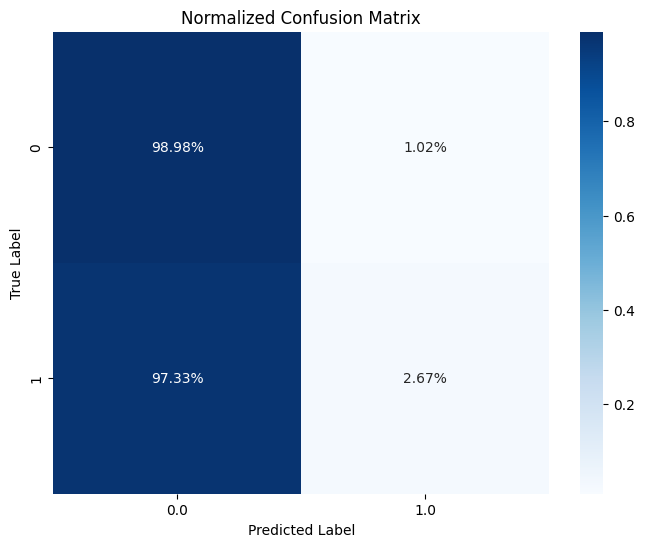


Metrics by class:



Class 0:
  Precision: 0.7225
  Recall: 0.9898
  F1-Score: 0.8353
  Support: 181393


[Stage 8042:======================>                                 (2 + 3) / 5]


Class 1:
  Precision: 0.5066
  Recall: 0.0267
  F1-Score: 0.0508
  Support: 70853


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.sql import functions as F

# 1. Get the best model from the cross-validator
best_model = cv_model.bestModel

# 2. Prepare the test dataset (apply the same transformations)
print(f"Test data size: {test_df.count()}")

# 3. Make predictions
predictions = best_model.transform(test_df)

# 4. Show some predictions
print("\nSample predictions:")
predictions.select("legal_action_taken", "prediction", "probability").show(10, truncate=False)

# 5. Evaluate metrics

# --- Binary Classification Metrics (AUC-ROC, AUC-PR) ---
binary_evaluator = BinaryClassificationEvaluator(
    labelCol="legal_action_taken",
    rawPredictionCol="rawPrediction"
)

auc = binary_evaluator.evaluate(predictions, {binary_evaluator.metricName: "areaUnderROC"})
auc_pr = binary_evaluator.evaluate(predictions, {binary_evaluator.metricName: "areaUnderPR"})

print(f"\nArea Under ROC Curve (AUC-ROC): {auc:.4f}")
print(f"Area Under PR Curve (AUC-PR): {auc_pr:.4f}")

# --- Multiclass Metrics (Accuracy, F1, Precision, Recall) ---
multiclass_evaluator = MulticlassClassificationEvaluator(
    labelCol="legal_action_taken",
    predictionCol="prediction"
)

accuracy = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "accuracy"})
precision = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "weightedPrecision"})
recall = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "weightedRecall"})
f1 = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "f1"})

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# 6. Confusion Matrix (Plotting Normalized)
print("\nConfusion Matrix (Raw Counts):")
# We calculate counts in Spark
conf_matrix_spark = predictions.groupBy("legal_action_taken", "prediction").count()
conf_matrix_spark.orderBy("legal_action_taken", "prediction").show()

# Convert to Pandas for plotting
cm_pd = conf_matrix_spark.toPandas()

# Create a pivot table: Index=Actual, Columns=Predicted
cm_pivot = cm_pd.pivot(index='legal_action_taken', columns='prediction', values='count').fillna(0)
# Sort index/columns to ensure order 0, 1...
cm_pivot = cm_pivot.sort_index(axis=0).sort_index(axis=1)

# Normalize by row (True Label) to get percentages
cm_normalized = cm_pivot.div(cm_pivot.sum(axis=1), axis=0)

# Plot using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', cbar=True)
plt.title('Normalized Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig("media/images/confusion_matrix.png")
plt.show()

# 7. Metrics by class
print("\nMetrics by class:")
for label in [0, 1]:
    tp = predictions.filter((F.col("legal_action_taken") == label) & (F.col("prediction") == label)).count()
    fp = predictions.filter((F.col("legal_action_taken") != label) & (F.col("prediction") == label)).count()
    fn = predictions.filter((F.col("legal_action_taken") == label) & (F.col("prediction") != label)).count()
    
    precision_class = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_class = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_class = 2 * (precision_class * recall_class) / (precision_class + recall_class) if (precision_class + recall_class) > 0 else 0
    
    print(f"\nClass {label}:")
    print(f"  Precision: {precision_class:.4f}")
    print(f"  Recall: {recall_class:.4f}")
    print(f"  F1-Score: {f1_class:.4f}")
    print(f"  Support: {tp + fn}")


                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
police_force_idx    0.392774
         age_idx    0.322959
         law_idx    0.123286
      reason_idx    0.060053
 search_type_idx    0.050290
      gender_idx    0.026274
            hour    0.011735
   ethnicity_idx    0.005250
       dayofyear    0.004602
       dayofweek    0.001845
           month    0.000933


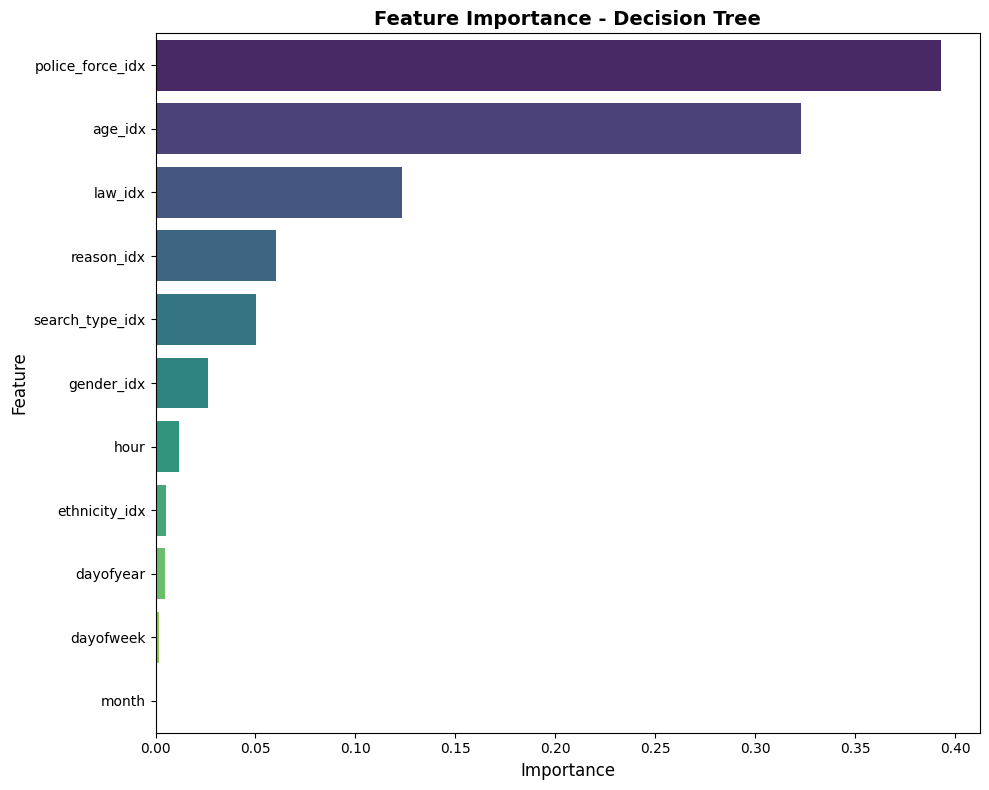


Total features: 11
Top feature: police_force_idx (0.3928)
Top 5 features account for: 94.94% of total importance

Feature importance saved to 'feature_importance.csv'


In [26]:
dt_model = best_model.stages[-1] 

feature_importances = dt_model.featureImportances.toArray()

categorical_cols = ["age", "gender", "law", "ethnicity", "search_type", "reason", "police_force"]
numeric_cols = ["hour", "month", "dayofweek", "dayofyear"]
feature_names = [f"{col}_idx" for col in categorical_cols] + numeric_cols

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE RANKING".center(60))
print("="*60)
print(importance_df.to_string(index=False))
print("="*60)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df, 
    x="Importance", 
    y="Feature", 
    hue="Feature",   
    palette="viridis", 
    legend=False
)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance - Decision Tree', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('media/images/feature_importance_bar_weighted.png', dpi=300, bbox_inches='tight')
plt.show()


# Additional statistics
print(f"\nTotal features: {len(feature_names)}")
print(f"Top feature: {importance_df.iloc[0]['Feature']} ({importance_df.iloc[0]['Importance']:.4f})")
print(f"Top 5 features account for: {importance_df.head(5)['Importance'].sum():.2%} of total importance")

importance_df.to_csv('media/results/feature_importance.csv', index=False)
print("\nFeature importance saved to 'feature_importance.csv'")

### 4.3 Cross Validator with weighted classes
As we can see the predictions are totatally wrong, the model is always predicting the no legal action taken class.

In [27]:
class_counts = train_df.groupBy("legal_action_taken").count().collect()

neg_count = [x['count'] for x in class_counts if x['legal_action_taken'] == 0][0]
pos_count = [x['count'] for x in class_counts if x['legal_action_taken'] == 1][0]
weight_ratio = neg_count / (neg_count+pos_count)

print(f" Unbalance: {neg_count:,} negatives vs {pos_count:,} positives")
print(f"   Ratio: {weight_ratio:.2f} vs {1-weight_ratio:.2f}")
print()

weighted_df= train_df.withColumn(
    "classWeight",
    F.when(F.col("legal_action_taken") == 1, weight_ratio).otherwise(1.0-weight_ratio)
)

[Stage 8047:==========================================>             (3 + 1) / 4]

 Unbalance: 820,408 negatives vs 302,208 positives
   Ratio: 0.73 vs 0.27



In [28]:
# Verify final dataset before pipeline
print(f"Final dataset count before pipeline: {df_final.count()}")
assert df_final.count() > 0, "Dataset is empty before pipeline!"

# 1. String Indexers
indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep") 
    for col in categorical_cols
]

# 2. Vector Assembler
numeric_cols = ["hour", "month", "dayofweek", "dayofyear"]
feature_cols = [f"{col}_idx" for col in categorical_cols] + numeric_cols
assembler = VectorAssembler(
    inputCols=feature_cols, 
    outputCol="features",
    handleInvalid="keep"
)

# 3. Decision Tree Estimator
dt = DecisionTreeClassifier(
    labelCol="legal_action_taken", 
    featuresCol="features",
    weightCol="classWeight",
    maxDepth=5, 
    maxBins=64, 
    seed=42
)

# 4. Construct the Pipeline
pipeline = Pipeline(stages=indexers + [assembler, dt])

# 5. Evaluator
evaluator = BinaryClassificationEvaluator(
    rawPredictionCol='rawPrediction',  # Changed from 'prediction'
    labelCol='legal_action_taken',
    metricName="areaUnderPR"
)

# 6. Parameter Grid
paramGrid = (ParamGridBuilder() 
    .addGrid(dt.maxDepth, [5, 10, ]) \
    .addGrid(dt.minInstancesPerNode, [5, 10]) \
    .addGrid(dt.maxBins, [ 64, 128]) \
    .addGrid(dt.impurity, ['gini', 'entropy']) \
    .build()
    )

# 7. Time Series Cross Validator
ts_cv = tsCrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=6,
    datetimeCol='timestamp',
    timeSplit=relativedelta(months=3),
    gap=None,
    disableExpandingWindow=False,
    parallelism=2
)

# 8. Fit with error handling
try:
    print("Starting Pipeline Training with Temporal Cross-Validation...")
    start_time = time.time()
    
    # This will call your custom _kFold logic internally
    cv_model = ts_cv.fit(weighted_df)
    
    total_time = time.time() - start_time
    print(f"Pipeline fitting complete. Total time: {total_time:.2f} seconds.")
    
    # Extract the Best Model and Audit the Bias
    best_model = cv_model.bestModel
    best_tree = best_model.stages[-1]
    
    print(f"Best Model MaxDepth: {best_tree.getOrDefault('maxDepth')}, MinInstancesPerNode: {best_tree.getOrDefault('minInstancesPerNode')},\
    MaxBins: {best_tree.getOrDefault('maxBins')},  Impurity: {best_tree.getOrDefault('impurity')}")
except Exception as e:
    print(f"Error during fitting: {e}")
    # Additional debugging
    print("\nDataset sample:")
    df_final.select("legal_action_taken", "timestamp", *categorical_cols[:3]).show(5)
    raise

Final dataset count before pipeline: 1403329
Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 540.47 seconds.
Best Model MaxDepth: 10, MinInstancesPerNode: 10,    MaxBins: 64,  Impurity: entropy


Test data size: 252246

Sample predictions:


+------------------+----------+-----------------------------------------+
|legal_action_taken|prediction|probability                              |
+------------------+----------+-----------------------------------------+
|0                 |1.0       |[0.4473837595779058,0.5526162404220942]  |
|0                 |0.0       |[0.615400889642629,0.38459911035737093]  |
|0                 |0.0       |[0.7835723927835295,0.21642760721647045] |
|0                 |0.0       |[0.5855131261456225,0.41448687385437755] |
|0                 |0.0       |[0.615400889642629,0.38459911035737093]  |
|0                 |0.0       |[0.9865971896848372,0.013402810315162819]|
|0                 |1.0       |[0.4471794823977266,0.5528205176022735]  |
|0                 |0.0       |[0.7385017097308034,0.2614982902691965]  |
|0                 |0.0       |[0.6811738656522365,0.3188261343477635]  |
|0                 |1.0       |[0.4471794823977266,0.5528205176022735]  |
+------------------+----------+-------


Area Under ROC Curve (AUC-ROC): 0.6003
Area Under PR Curve (AUC-PR): 0.3362



Accuracy: 0.5532
Weighted Precision: 0.6953
Weighted Recall: 0.5532
F1 Score: 0.5718

Confusion Matrix (Raw Counts):


+------------------+----------+-----+
|legal_action_taken|prediction|count|
+------------------+----------+-----+
|                 0|       0.0|86831|
|                 0|       1.0|94562|
|                 1|       0.0|18147|
|                 1|       1.0|52706|
+------------------+----------+-----+



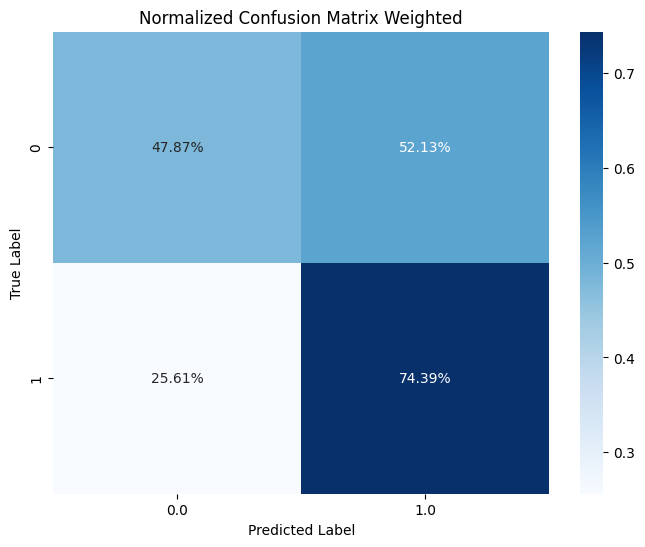


Metrics by class:



Class 0:
  Precision: 0.8271
  Recall: 0.4787
  F1-Score: 0.6064
  Support: 181393


[Stage 15880:===========>                                           (1 + 4) / 5]


Class 1:
  Precision: 0.3579
  Recall: 0.7439
  F1-Score: 0.4833
  Support: 70853


In [29]:
# 1. Get the best model from the cross-validator
best_model = cv_model.bestModel

# 2. Prepare the test dataset (apply the same transformations)
print(f"Test data size: {test_df.count()}")

# 3. Make predictions
predictions = best_model.transform(test_df)

# 4. Show some predictions
print("\nSample predictions:")
predictions.select("legal_action_taken", "prediction", "probability").show(10, truncate=False)

# 5. Evaluate metrics

# --- Binary Classification Metrics (AUC-ROC, AUC-PR) ---
binary_evaluator = BinaryClassificationEvaluator(
    labelCol="legal_action_taken",
    rawPredictionCol="rawPrediction"
)

auc = binary_evaluator.evaluate(predictions, {binary_evaluator.metricName: "areaUnderROC"})
auc_pr = binary_evaluator.evaluate(predictions, {binary_evaluator.metricName: "areaUnderPR"})

print(f"\nArea Under ROC Curve (AUC-ROC): {auc:.4f}")
print(f"Area Under PR Curve (AUC-PR): {auc_pr:.4f}")

# --- Multiclass Metrics (Accuracy, F1, Precision, Recall) ---
multiclass_evaluator = MulticlassClassificationEvaluator(
    labelCol="legal_action_taken",
    predictionCol="prediction"
)

accuracy = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "accuracy"})
precision = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "weightedPrecision"})
recall = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "weightedRecall"})
f1 = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "f1"})

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# 6. Confusion Matrix (Plotting Normalized)
print("\nConfusion Matrix (Raw Counts):")
# We calculate counts in Spark
conf_matrix_spark = predictions.groupBy("legal_action_taken", "prediction").count()
conf_matrix_spark.orderBy("legal_action_taken", "prediction").show()

# Convert to Pandas for plotting
cm_pd = conf_matrix_spark.toPandas()

# Create a pivot table: Index=Actual, Columns=Predicted
cm_pivot = cm_pd.pivot(index='legal_action_taken', columns='prediction', values='count').fillna(0)
# Sort index/columns to ensure order 0, 1...
cm_pivot = cm_pivot.sort_index(axis=0).sort_index(axis=1)

# Normalize by row (True Label) to get percentages
cm_normalized = cm_pivot.div(cm_pivot.sum(axis=1), axis=0)

# Plot using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', cbar=True)
plt.title('Normalized Confusion Matrix Weighted')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig("media/images/confusion_matrix_weighted.png")
plt.show()

# 7. Metrics by class
print("\nMetrics by class:")
for label in [0, 1]:
    tp = predictions.filter((F.col("legal_action_taken") == label) & (F.col("prediction") == label)).count()
    fp = predictions.filter((F.col("legal_action_taken") != label) & (F.col("prediction") == label)).count()
    fn = predictions.filter((F.col("legal_action_taken") == label) & (F.col("prediction") != label)).count()
    
    precision_class = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_class = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_class = 2 * (precision_class * recall_class) / (precision_class + recall_class) if (precision_class + recall_class) > 0 else 0
    
    print(f"\nClass {label}:")
    print(f"  Precision: {precision_class:.4f}")
    print(f"  Recall: {recall_class:.4f}")
    print(f"  F1-Score: {f1_class:.4f}")
    print(f"  Support: {tp + fn}")


                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
police_force_idx    0.406196
         age_idx    0.292285
         law_idx    0.130181
      reason_idx    0.069279
 search_type_idx    0.040838
      gender_idx    0.030394
            hour    0.014255
       dayofyear    0.007218
   ethnicity_idx    0.005504
       dayofweek    0.002569
           month    0.001280


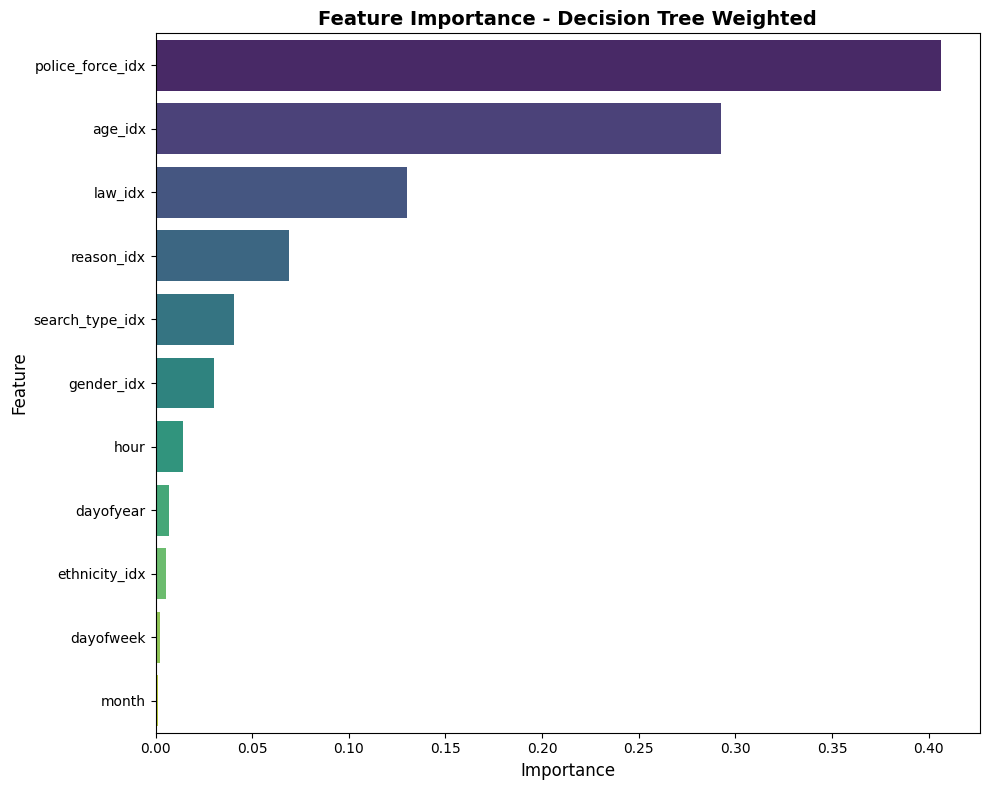


Total features: 11
Top feature: police_force_idx (0.4062)
Top 5 features account for: 93.88% of total importance

Feature importance saved to 'feature_importance_weighted.csv'


In [30]:
dt_model = best_model.stages[-1] 

feature_importances = dt_model.featureImportances.toArray()

categorical_cols = ["age", "gender", "law", "ethnicity", "search_type", "reason", "police_force"]
numeric_cols = ["hour", "month", "dayofweek", "dayofyear"]
feature_names = [f"{col}_idx" for col in categorical_cols] + numeric_cols

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE RANKING".center(60))
print("="*60)
print(importance_df.to_string(index=False))
print("="*60)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df, 
    x="Importance", 
    y="Feature", 
    hue="Feature",   
    palette="viridis", 
    legend=False
)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance - Decision Tree Weighted', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('media/images/feature_importance_bar_weighted.png', dpi=300, bbox_inches='tight')
plt.show()


# Additional statistics
print(f"\nTotal features: {len(feature_names)}")
print(f"Top feature: {importance_df.iloc[0]['Feature']} ({importance_df.iloc[0]['Importance']:.4f})")
print(f"Top 5 features account for: {importance_df.head(5)['Importance'].sum():.2%} of total importance")

importance_df.to_csv('media/results/feature_importance_weighted.csv', index=False)
print("\nFeature importance saved to 'feature_importance_weighted.csv'")

### 4.4 Cross Validator with Balanced Dataset

In [31]:
from pyspark.sql import functions as F

def balance_by_year_optimized(df, label_col='legal_action_taken', year_col='year'):
    # 1. Calculate counts per year and label (this returns a lowercase DF)
    counts = df.groupBy(year_col, label_col).count().withColumnRenamed("count", "actual_count")
    
    # 2. Calculate the target count (the minimum for each class) for each year
    # If in 2020 there are 1,000 positive and 100 negative, the target is 100
    targets = counts.groupBy(year_col).agg(F.min("actual_count").alias("target_count"))
    
    # 3. Calculate the sampling fraction (target/actual)
    # Example: Positive (100/1000 = 0.1), Negative (100/100 = 1.0)
    fractions = counts.join(targets, on=year_col) \
                      .withColumn("fraction", F.col("target_count") / F.col("actual_count")) \
                      .select(year_col, label_col, "fraction")
    
    # 4. Merge the fractions with the original DF and filter
    # IMPORTANT: We use ‘broadcast’ because ‘fractions’ is diminutive
    # This avoids heavy data movement
    balanced_df = df.join(F.broadcast(fractions), on=[year_col, label_col]) \
                    .filter(F.rand(seed=42) <= F.col("fraction")) \
                    .drop("fraction")
    
    return balanced_df

# --- CRITICAL STEP BEFORE THE PIPELINE ---

# 1. Apply the balance
train_balanced = balance_by_year_optimized(train_df, label_col='legal_action_taken', year_col='year')
train_balanced = train_balanced.cache()

# 3. Force execution now to ensure that balancing works before entering the pipeline
print(f"Balanced dataset size: {train_balanced.count()}")

[Stage 15894:=========================================>             (3 + 1) / 4]

Balanced dataset size: 604834


In [32]:
# Verify final dataset before pipeline
print(f"Final dataset count before pipeline: {df_final.count()}")
assert df_final.count() > 0, "Dataset is empty before pipeline!"

# 1. String Indexers
indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep") 
    for col in categorical_cols
]

# 2. Vector Assembler
numeric_cols = ["hour", "month", "dayofweek", "dayofyear"]
feature_cols = [f"{col}_idx" for col in categorical_cols] + numeric_cols
assembler = VectorAssembler(
    inputCols=feature_cols, 
    outputCol="features",
    handleInvalid="keep"
)

# 3. Decision Tree Estimator
dt = DecisionTreeClassifier(
    labelCol="legal_action_taken", 
    featuresCol="features",
    maxDepth=5, 
    maxBins=64, 
    seed=42
)

# 4. Construct the Pipeline
pipeline = Pipeline(stages=indexers + [assembler, dt])

# 5. Evaluator
evaluator = BinaryClassificationEvaluator(
    rawPredictionCol='rawPrediction',  # Changed from 'prediction'
    labelCol='legal_action_taken',
    metricName="areaUnderPR"
)

# 6. Parameter Grid
paramGrid = (ParamGridBuilder() 
    .addGrid(dt.maxDepth, [5, 10, ]) \
    .addGrid(dt.minInstancesPerNode, [5, 10]) \
    .addGrid(dt.maxBins, [ 64, 128]) \
    .addGrid(dt.impurity, ['gini', 'entropy']) \
    .build()
    )

# 7. Time Series Cross Validator
ts_cv = tsCrossValidator(
    estimator=pipeline,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=6,
    datetimeCol='timestamp',
    timeSplit=relativedelta(months=3),
    gap=None,
    disableExpandingWindow=False,
    parallelism=2
)

# 8. Fit with error handling
try:
    print("Starting Pipeline Training with Temporal Cross-Validation...")
    start_time = time.time()
    
    # This will call your custom _kFold logic internally
    cv_model = ts_cv.fit(train_balanced)
    
    total_time = time.time() - start_time
    print(f"Pipeline fitting complete. Total time: {total_time:.2f} seconds.")
    
    # Extract the Best Model and Audit the Bias
    best_model = cv_model.bestModel
    best_tree = best_model.stages[-1]
    
    print(f"Best Model MaxDepth: {best_tree.getOrDefault('maxDepth')}, MinInstancesPerNode: {best_tree.getOrDefault('minInstancesPerNode')},\
    MaxBins: {best_tree.getOrDefault('maxBins')},  Impurity: {best_tree.getOrDefault('impurity')}")
except Exception as e:
    print(f"Error during fitting: {e}")
    # Additional debugging
    print("\nDataset sample:")
    df_final.select("legal_action_taken", "timestamp", *categorical_cols[:3]).show(5)
    raise

Final dataset count before pipeline: 1403329
Starting Pipeline Training with Temporal Cross-Validation...


Pipeline fitting complete. Total time: 325.34 seconds.
Best Model MaxDepth: 10, MinInstancesPerNode: 10,    MaxBins: 128,  Impurity: entropy


Test data size: 252246

Sample predictions:


+------------------+----------+-----------------------------------------+
|legal_action_taken|prediction|probability                              |
+------------------+----------+-----------------------------------------+
|0                 |0.0       |[0.7258270458502611,0.2741729541497388]  |
|0                 |0.0       |[0.8490566037735849,0.1509433962264151]  |
|0                 |0.0       |[0.7904191616766467,0.20958083832335328] |
|0                 |0.0       |[0.7258270458502611,0.2741729541497388]  |
|0                 |0.0       |[0.617046818727491,0.382953181272509]    |
|0                 |0.0       |[0.9868995633187773,0.013100436681222707]|
|0                 |1.0       |[0.4711864406779661,0.5288135593220339]  |
|0                 |0.0       |[0.8148148148148148,0.18518518518518517] |
|0                 |0.0       |[0.7222222222222222,0.2777777777777778]  |
|0                 |1.0       |[0.4711864406779661,0.5288135593220339]  |
+------------------+----------+-------


Area Under ROC Curve (AUC-ROC): 0.6000
Area Under PR Curve (AUC-PR): 0.3357



Accuracy: 0.5532
Weighted Precision: 0.6973
Weighted Recall: 0.5532
F1 Score: 0.5716

Confusion Matrix (Raw Counts):


+------------------+----------+-----+
|legal_action_taken|prediction|count|
+------------------+----------+-----+
|                 0|       0.0|86436|
|                 0|       1.0|94957|
|                 1|       0.0|17751|
|                 1|       1.0|53102|
+------------------+----------+-----+



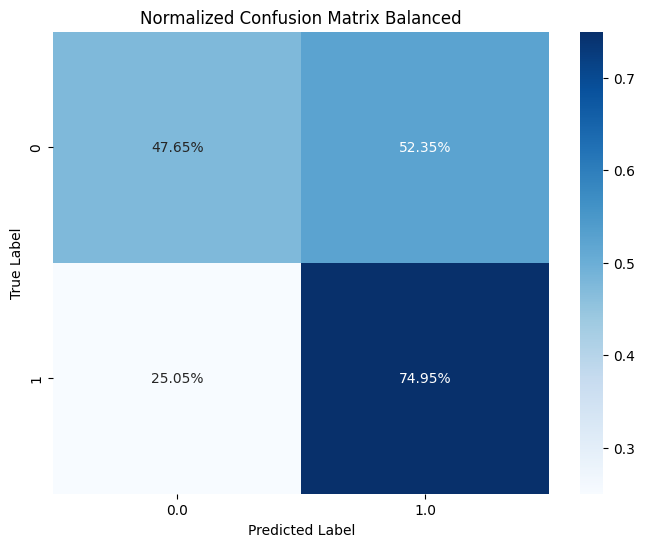


Metrics by class:



Class 0:
  Precision: 0.8296
  Recall: 0.4765
  F1-Score: 0.6053
  Support: 181393


[Stage 23836:======================>                                (2 + 3) / 5]


Class 1:
  Precision: 0.3587
  Recall: 0.7495
  F1-Score: 0.4851
  Support: 70853


In [33]:
# 1. Get the best model from the cross-validator
best_model = cv_model.bestModel

# 2. Prepare the test dataset (apply the same transformations)
print(f"Test data size: {test_df.count()}")

# 3. Make predictions
predictions = best_model.transform(test_df)

# 4. Show some predictions
print("\nSample predictions:")
predictions.select("legal_action_taken", "prediction", "probability").show(10, truncate=False)

# 5. Evaluate metrics

# --- Binary Classification Metrics (AUC-ROC, AUC-PR) ---
binary_evaluator = BinaryClassificationEvaluator(
    labelCol="legal_action_taken",
    rawPredictionCol="rawPrediction"
)

auc = binary_evaluator.evaluate(predictions, {binary_evaluator.metricName: "areaUnderROC"})
auc_pr = binary_evaluator.evaluate(predictions, {binary_evaluator.metricName: "areaUnderPR"})

print(f"\nArea Under ROC Curve (AUC-ROC): {auc:.4f}")
print(f"Area Under PR Curve (AUC-PR): {auc_pr:.4f}")

# --- Multiclass Metrics (Accuracy, F1, Precision, Recall) ---
multiclass_evaluator = MulticlassClassificationEvaluator(
    labelCol="legal_action_taken",
    predictionCol="prediction"
)

accuracy = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "accuracy"})
precision = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "weightedPrecision"})
recall = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "weightedRecall"})
f1 = multiclass_evaluator.evaluate(predictions, {multiclass_evaluator.metricName: "f1"})

print(f"\nAccuracy: {accuracy:.4f}")
print(f"Weighted Precision: {precision:.4f}")
print(f"Weighted Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")

# 6. Confusion Matrix (Plotting Normalized)
print("\nConfusion Matrix (Raw Counts):")
# We calculate counts in Spark
conf_matrix_spark = predictions.groupBy("legal_action_taken", "prediction").count()
conf_matrix_spark.orderBy("legal_action_taken", "prediction").show()

# Convert to Pandas for plotting
cm_pd = conf_matrix_spark.toPandas()

# Create a pivot table: Index=Actual, Columns=Predicted
cm_pivot = cm_pd.pivot(index='legal_action_taken', columns='prediction', values='count').fillna(0)
# Sort index/columns to ensure order 0, 1...
cm_pivot = cm_pivot.sort_index(axis=0).sort_index(axis=1)

# Normalize by row (True Label) to get percentages
cm_normalized = cm_pivot.div(cm_pivot.sum(axis=1), axis=0)

# Plot using Seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues', cbar=True)
plt.title('Normalized Confusion Matrix Balanced')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig("media/images/confusion_matrix_balanced.png")
plt.show()

# 7. Metrics by class
print("\nMetrics by class:")
for label in [0, 1]:
    tp = predictions.filter((F.col("legal_action_taken") == label) & (F.col("prediction") == label)).count()
    fp = predictions.filter((F.col("legal_action_taken") != label) & (F.col("prediction") == label)).count()
    fn = predictions.filter((F.col("legal_action_taken") == label) & (F.col("prediction") != label)).count()
    
    precision_class = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall_class = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1_class = 2 * (precision_class * recall_class) / (precision_class + recall_class) if (precision_class + recall_class) > 0 else 0
    
    print(f"\nClass {label}:")
    print(f"  Precision: {precision_class:.4f}")
    print(f"  Recall: {recall_class:.4f}")
    print(f"  F1-Score: {f1_class:.4f}")
    print(f"  Support: {tp + fn}")


                 FEATURE IMPORTANCE RANKING                 
         Feature  Importance
police_force_idx    0.400817
         age_idx    0.276314
         law_idx    0.132167
      reason_idx    0.073164
 search_type_idx    0.043946
      gender_idx    0.031605
            hour    0.024650
       dayofyear    0.007794
   ethnicity_idx    0.005311
       dayofweek    0.002869
           month    0.001364


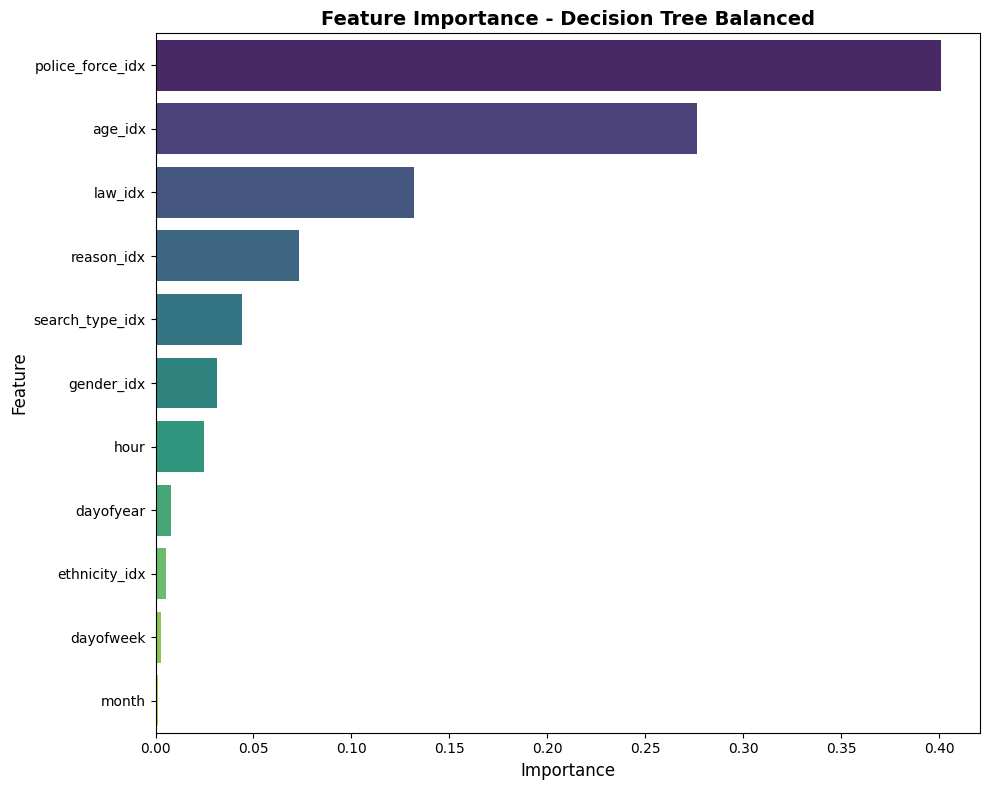


Total features: 11
Top feature: police_force_idx (0.4008)
Top 5 features account for: 92.64% of total importance

Feature importance saved to 'feature_importance_balanced.csv'


In [34]:
dt_model = best_model.stages[-1] 

feature_importances = dt_model.featureImportances.toArray()

categorical_cols = ["age", "gender", "law", "ethnicity", "search_type", "reason", "police_force"]
numeric_cols = ["hour", "month", "dayofweek", "dayofyear"]
feature_names = [f"{col}_idx" for col in categorical_cols] + numeric_cols

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': feature_importances
}).sort_values('Importance', ascending=False)

print("\n" + "="*60)
print("FEATURE IMPORTANCE RANKING".center(60))
print("="*60)
print(importance_df.to_string(index=False))
print("="*60)

plt.figure(figsize=(10, 8))
sns.barplot(
    data=importance_df, 
    x="Importance", 
    y="Feature", 
    hue="Feature",   
    palette="viridis", 
    legend=False
)
plt.xlabel('Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.title('Feature Importance - Decision Tree Balanced', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('media/images/feature_importance_balanced.png', dpi=300, bbox_inches='tight')
plt.show()


# Additional statistics
print(f"\nTotal features: {len(feature_names)}")
print(f"Top feature: {importance_df.iloc[0]['Feature']} ({importance_df.iloc[0]['Importance']:.4f})")
print(f"Top 5 features account for: {importance_df.head(5)['Importance'].sum():.2%} of total importance")

importance_df.to_csv('media/results/feature_importance_balanced.csv', index=False)
print("\nFeature importance saved to 'feature_importance_balanced.csv'")

## 5. Scalabilty study: Size up, Scale up and Speed up

In [43]:
import subprocess
import pandas as pd

file="media/scalability_results.csv"
def run_scalability(study_type, cores, percentage, times=10, results_file=file):
    cmd = ["python3", "scripts/scalability_worker.py", study_type, str(times), str(cores), str(percentage), results_file]
    process = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)
    stdout, stderr = process.communicate()
    if stderr: print(f"Error: {stderr}")

# Create results file
with open("media/scalability_results.csv", "w") as f:
    f.write("study_type,study_id,run_id,cores,percentage,runtime\n")

# Define Size (data %) and Speed (cores) values
sizes = [10, 20, 30, 40, 60, 80, 100]
cores = [1, 2, 3, 4]

### 5.1 Size-up

In [44]:
for p in sizes:
    print(f"--- Running Size-up: {p}% Data ---")
    run_scalability(study_type='size-up', cores=4, percentage=p)

--- Running Size-up: 10% Data ---
Error: WARNING: Using incubator modules: jdk.incubator.vector
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/11 09:57:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/01/11 09:57:51 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.

[Stage 1:=============================>                             (2 + 2) / 4]

[Stage 1:============================================>              (3 + 1) / 4]

[Stage 3:>                                                          (0 + 4) / 4]

                                                                                
26/01/11 09:58:01 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavio

### 5.2 Speed-up

In [45]:
for c in cores:
    print(f"--- Running Speed-up: {c} Cores ---")
    run_scalability(study_type='speed-up', cores=c, percentage=100)

--- Running Speed-up: 1 Cores ---
Error: WARNING: Using incubator modules: jdk.incubator.vector
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/11 10:06:51 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/01/11 10:06:52 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.

[Stage 0:>                                                          (0 + 1) / 1]

                                                                                

[Stage 1:>                                                          (0 + 1) / 1]

[Stage 1:===========================================================(1 + 0) / 1]

[Stage 3:>                                                          (0 + 1) / 1]

                                        

### 5.3 Scale-up

In [46]:
for p, c in zip(sizes[:4], cores):
    print(f"--- Running Scale-up: {p}% Data | {c} Cores ---")
    run_scalability(study_type='scale-up', cores=c, percentage=p)

--- Running Scale-up: 10% Data | 1 Cores ---
Error: WARNING: Using incubator modules: jdk.incubator.vector
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/01/11 10:17:12 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/01/11 10:17:13 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.

[Stage 1:>                                                          (0 + 1) / 1]

[Stage 1:===========================================================(1 + 0) / 1]

[Stage 3:>                                                          (0 + 1) / 1]

                                                                                
26/01/11 10:17:22 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. T

## 6. Scalability Study Analysis
Lets analyze the results obtained from the three different scalability studies

In [47]:
import sys
import pandas as pd
from matplotlib import pyplot as plt

def plot_scalability_global(name, stats, xlabel, x_vals, linear_vals, xticks, ax):
    
    ax.set_title(f"{name.capitalize()} of the Decision Tree")
    ax.plot(x_vals, stats, 'k', label=f"Real {name}")
    ax.plot(x_vals, linear_vals, '--', color='gray', label=f"Linear {name}", linewidth=1)
    ax.set(xlabel=xlabel, ylabel=name.capitalize())
    ax.set_xticks(xticks)
    ax.legend()   
     
    if name == 'scale-up': ax.set_ylim([0, 1.1])

In [48]:
file = "media/scalability_results.csv"
results_scalability = pd.read_csv(file)
results_scalability.head()

,study_type,study_id,run_id,cores,percentage,runtime
0,size-up,fb20abe5b62505bfede9b1235e1cd135,0,4,10,2.595644
1,size-up,fb20abe5b62505bfede9b1235e1cd135,1,4,10,2.603951
2,size-up,fb20abe5b62505bfede9b1235e1cd135,2,4,10,2.638915
3,size-up,fb20abe5b62505bfede9b1235e1cd135,3,4,10,2.294837
4,size-up,fb20abe5b62505bfede9b1235e1cd135,4,4,10,2.412316


### 6.1 Size-up Study Results
We select the experiments related to size-up study and we compute the mean, median and standard deviation of runtime

In [49]:
size_up_results = (
    results_scalability[results_scalability["study_type"] == "size-up"]
    .groupby("study_id")
    .agg(
        mean_runtime=("runtime", "mean"),
        median_runtime=("runtime", "median"),
        std_runtime=("runtime", "std"),
        percentage=("percentage", "first"),
    )
    .sort_values(by="percentage")
).reset_index()
size_up_results

,study_id,mean_runtime,median_runtime,std_runtime,percentage
0,fb20abe5b62505bfede9b1235e1cd135,2.425556,2.418953,0.180742,10
1,b60c6be64ebdb5bc6ef4a4af9a49b128,2.836585,2.721924,0.388771,20
2,463eea9301e6e0afdf3cce22344c2327,3.327078,3.211900,0.309082,30
3,a2426dfbf4df3721ff85dbd2ef8e4f55,3.656660,3.604478,0.170664,40
4,c8ca0a9be3aeb8e26ad9d35d74f6fa8b,4.717096,4.730497,0.232621,60
5,eaa3a30dea6bccad00690174b4581a91,5.684273,5.681669,0.532767,80
6,cc8f5417cda23252713c64d38614d10e,6.547432,6.654473,0.422946,100


Now we are going to compute the actual size-up ("real_size_up_factor") values. To do so, we will use the runtime median values, as they will have less noise than the mean runtime values. As baseline, we will take the first median runtime from the first percentage value (10%).

In [50]:
# Baselines
baseline_median = size_up_results.loc[0, "median_runtime"]
baseline_percentage = size_up_results.loc[0, "percentage"]

# Real size-up factor
size_up_results["real_size_up_factor"] = (
    size_up_results["median_runtime"] / baseline_median
)

# Linear (ideal) size-up factor
size_up_results["linear_size_up_factor"] = (
    size_up_results["percentage"] / baseline_percentage
)

size_up_results

,study_id,mean_runtime,median_runtime,std_runtime,percentage,real_size_up_factor,linear_size_up_factor
0,fb20abe5b62505bfede9b1235e1cd135,2.425556,2.418953,0.180742,10,1.000000,1.0
1,b60c6be64ebdb5bc6ef4a4af9a49b128,2.836585,2.721924,0.388771,20,1.125249,2.0
2,463eea9301e6e0afdf3cce22344c2327,3.327078,3.211900,0.309082,30,1.327806,3.0
3,a2426dfbf4df3721ff85dbd2ef8e4f55,3.656660,3.604478,0.170664,40,1.490098,4.0
4,c8ca0a9be3aeb8e26ad9d35d74f6fa8b,4.717096,4.730497,0.232621,60,1.955597,6.0
5,eaa3a30dea6bccad00690174b4581a91,5.684273,5.681669,0.532767,80,2.348813,8.0
6,cc8f5417cda23252713c64d38614d10e,6.547432,6.654473,0.422946,100,2.750972,10.0


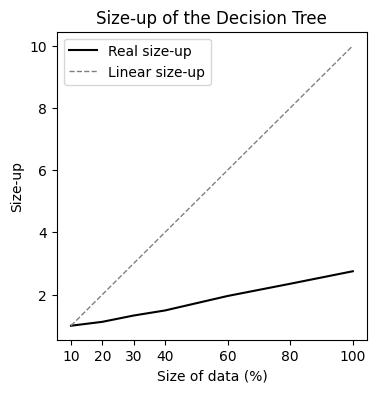

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
plot_scalability_global('size-up', size_up_results['real_size_up_factor'], "Size of data (%)", sizes, size_up_results['linear_size_up_factor'], sizes, ax)
plt.savefig(f"media/images/size_up.svg", bbox_inches="tight", pad_inches=0.0, dpi=80)
plt.show()

### 6.2 Speed-up Study Results
We select the experiments related to speed-up study and we compute the mean, median and standard deviation of runtime

In [52]:
speed_up_results = (
    results_scalability[results_scalability["study_type"] == "speed-up"]
    .groupby("study_id")
    .agg(
        mean_runtime=("runtime", "mean"),
        median_runtime=("runtime", "median"),
        std_runtime=("runtime", "std"),
        cores=("cores", "first"),
    )
    .sort_values(by="cores")
).reset_index()
speed_up_results

,study_id,mean_runtime,median_runtime,std_runtime,cores
0,891ccef9ee590938a11c562f44c1995f,16.058665,15.892133,0.507489,1
1,a4d16de5036552b50d728b027fdde7df,9.313635,9.333119,0.280443,2
2,e6de6002c8fe74bdc09b8646b73d94db,7.050598,6.887491,0.374682,3
3,e2ad448b6698058e07af4c17d328d7e1,6.413687,6.357200,0.242393,4


Now we are going to compute the actual speed-up ("real_speed_up_factor") values. To do so, we will use the runtime median values, as they will have less noise than the mean runtime values. As baseline, we will take the first median runtime from the first cores value (1).

In [53]:
# Baselines
baseline_median = speed_up_results.loc[0, "median_runtime"]
baseline_core = speed_up_results.loc[0, "cores"]

# Real speed-up factor
speed_up_results["real_speed_up_factor"] = (
    baseline_median / speed_up_results["median_runtime"]
)

# Linear (ideal) speed-up factor
speed_up_results["linear_speed_up_factor"] = (
    speed_up_results["cores"] / baseline_core
)

speed_up_results

,study_id,mean_runtime,median_runtime,std_runtime,cores,real_speed_up_factor,linear_speed_up_factor
0,891ccef9ee590938a11c562f44c1995f,16.058665,15.892133,0.507489,1,1.000000,1.0
1,a4d16de5036552b50d728b027fdde7df,9.313635,9.333119,0.280443,2,1.702768,2.0
2,e6de6002c8fe74bdc09b8646b73d94db,7.050598,6.887491,0.374682,3,2.307391,3.0
3,e2ad448b6698058e07af4c17d328d7e1,6.413687,6.357200,0.242393,4,2.499864,4.0


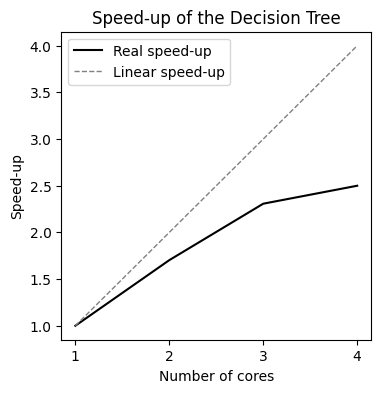

In [54]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
plot_scalability_global('speed-up', speed_up_results['real_speed_up_factor'], "Number of cores", cores, speed_up_results['linear_speed_up_factor'], cores, ax)
plt.savefig(f"media/images/speed_up.svg", bbox_inches="tight", pad_inches=0.0, dpi=80)
plt.show()

### 6.3 Scale-up Study Results
We select the experiments related to scale-up study and we compute the mean, median and standard deviation of runtime

In [55]:
scale_up_results = (
    results_scalability[results_scalability["study_type"] == "scale-up"]
    .groupby("study_id")
    .agg(
        mean_runtime=("runtime", "mean"),
        median_runtime=("runtime", "median"),
        std_runtime=("runtime", "std"),
        cores=("cores", "first"),
        percentage=("percentage", "first"),
    )
    .sort_values(by=["cores", "percentage"])
).reset_index()
scale_up_results

,study_id,mean_runtime,median_runtime,std_runtime,cores,percentage
0,3fe8a79480ea39e71e67435626a066a2,2.896655,2.795927,0.426930,1,10
1,fbcdcefd56ef15e20a31e5d0a58a6cb9,3.149666,3.178936,0.255840,2,20
2,7778aa1d632760157a82e3825d98d66b,3.472841,3.495027,0.194652,3,30
3,4cfe0e80ac35fb30d8de7b6ba9a4e39b,3.741938,3.735757,0.269978,4,40


Now we are going to compute the actual scale-up ("real_scale_up_factor") values. To do so, we will use the runtime median values, as they will have less noise than the mean runtime values. As baseline, we will take the first median runtime from the first study (the one with 10% of data and 1 core).

In [56]:
# Baselines
baseline_median = scale_up_results.loc[0, "median_runtime"]

# Real scale-up factor
scale_up_results["real_scale_up_factor"] = (
    baseline_median / scale_up_results["median_runtime"]
)

# Linear (ideal) speed-up factor = 1
scale_up_results["linear_scale_up_factor"] = (
    scale_up_results["median_runtime"] / scale_up_results["median_runtime"]
)

scale_up_results

,study_id,mean_runtime,median_runtime,std_runtime,cores,percentage,real_scale_up_factor,linear_scale_up_factor
0,3fe8a79480ea39e71e67435626a066a2,2.896655,2.795927,0.426930,1,10,1.000000,1.0
1,fbcdcefd56ef15e20a31e5d0a58a6cb9,3.149666,3.178936,0.255840,2,20,0.879517,1.0
2,7778aa1d632760157a82e3825d98d66b,3.472841,3.495027,0.194652,3,30,0.799973,1.0
3,4cfe0e80ac35fb30d8de7b6ba9a4e39b,3.741938,3.735757,0.269978,4,40,0.748423,1.0


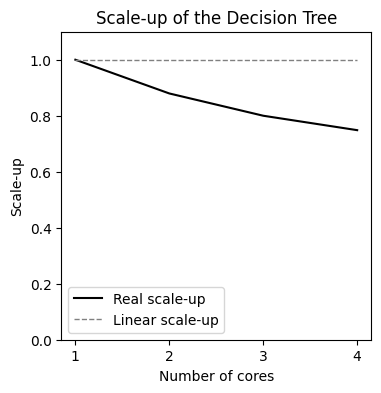

In [57]:
fig, ax = plt.subplots(1, 1, figsize=(4, 4))
plot_scalability_global('scale-up', scale_up_results['real_scale_up_factor'], "Number of cores", cores, scale_up_results['linear_scale_up_factor'], cores, ax)
plt.savefig(f"media/images/scale_up.svg", bbox_inches="tight", pad_inches=0.0, dpi=80)
plt.show()

### 6.4 Scalability Study Summary

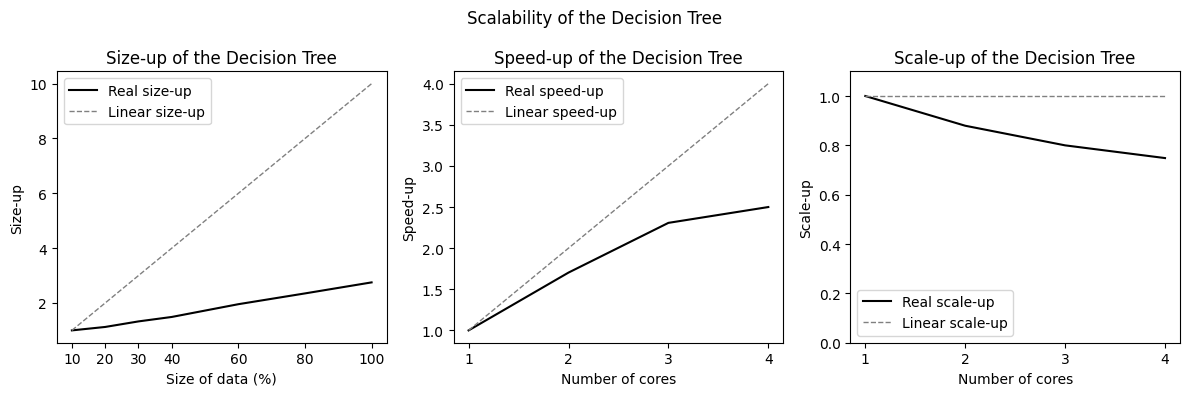

In [58]:
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle(f"Scalability of the Decision Tree")
plot_scalability_global('size-up', size_up_results['real_size_up_factor'], "Size of data (%)", sizes, size_up_results['linear_size_up_factor'], sizes, ax[0])
plot_scalability_global('speed-up', speed_up_results['real_speed_up_factor'], "Number of cores", cores, speed_up_results['linear_speed_up_factor'], cores, ax[1])
plot_scalability_global('scale-up', scale_up_results['real_scale_up_factor'], "Number of cores", cores, scale_up_results['linear_scale_up_factor'], cores, ax[2])
plt.tight_layout()
plt.savefig(f"media/images/scalability_global_overview.svg", bbox_inches="tight", pad_inches=0.0, dpi=80)
plt.show()

## 7. Bias Audit: Feature Importance Analysis

This study examines potential bias in police behaviour by partitioning the data into three temporal periods (2022–23, 2024, and 2025) to analyse how decision-making evolved over time. Decision Tree models combined with SHAP analysis were used to assess feature importance and the direction of their influence on predictions. Model performance was evaluated using confusion matrices, enabling us to distinguish genuine policy changes from statistical noise.

In [85]:
import os
import time
import pandas as pd
import numpy as np
from pyspark.sql.functions import rand
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from pyspark.ml import Pipeline
from pyspark.ml.functions import vector_to_array
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import DecisionTreeClassifier, RandomForestClassifier
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator
from pyspark.ml.linalg import Vectors, VectorUDT

from dateutil.relativedelta import relativedelta

from pyspark.sql import functions as F
from pyspark.sql.functions import udf
from pyspark.sql.types import ArrayType, DoubleType

# UDF for converting a vector into an array
vector_to_array = udf(lambda v: v.toArray().tolist(), ArrayType(DoubleType()))

### 7.1 Function Definitions

The following function trains a weighted Decision Tree classifier using a Spark ML pipeline. It first computes class imbalance in the target variable (legal_action_taken) and assigns inverse-frequency class weights to mitigate bias during training. Categorical features are encoded using StringIndexer, and all features are combined into a single vector with VectorAssembler. A Decision Tree model is then trained with fixed hyperparameters to ensure reproducibility and comparability.

In [86]:
def train_dt(
    train_df,
    categorical_cols,
    numeric_cols,
    feature_cols
):
    # 1) Weight model
    class_counts = train_df.groupBy("legal_action_taken").count().collect()

    neg_count = [x['count'] for x in class_counts if x['legal_action_taken'] == 0][0]
    pos_count = [x['count'] for x in class_counts if x['legal_action_taken'] == 1][0]
    weight_ratio = neg_count / (neg_count+pos_count)
    
    print(f" Unbalance: {neg_count:,} ({weight_ratio*100:.2f}%) negatives vs {pos_count:,} ({(1-weight_ratio)*100:.2f}%) positives")
    print()

    weighted_df= train_df.withColumn(
        "classWeight",
        F.when(F.col("legal_action_taken") == 1, weight_ratio).otherwise(1.0-weight_ratio)
    )

    # 2. String Indexers
    indexers = [
        StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep") 
        for col in categorical_cols
    ]
    
    # 3. Vector Assembler
    assembler = VectorAssembler(
        inputCols=feature_cols, 
        outputCol="features",
        handleInvalid="keep"
    )
    
    # 4. Decision Tree Estimator
    dt = DecisionTreeClassifier(
        labelCol="legal_action_taken", 
        featuresCol="features", 
        weightCol="classWeight",
        maxDepth=10, 
        maxBins=128,
        minInstancesPerNode=5,
        impurity="gini",
        seed=42
    )
    
    # 5. Construct the Pipeline
    pipeline = Pipeline(stages=indexers + [assembler, dt])
    
    # 6. Evaluator
    evaluator = BinaryClassificationEvaluator(
        rawPredictionCol='rawPrediction',  
        labelCol='legal_action_taken',
        metricName="areaUnderPR"
    )
    
    # 7. Fit with error handling
    try:
        print("Starting Pipeline Training...")
        start_time = time.time()
        
        # This will call your custom _kFold logic internally
        trained_pipeline = pipeline.fit(weighted_df)
        
        total_time = time.time() - start_time
        print(f"Pipeline fitting complete. Total time: {total_time:.2f} seconds.")
        
    except Exception as e:
        print(f"Error during fitting: {e}")
        # Additional debugging
        print("\nDataset sample:")
        df_final.select("legal_action_taken", "timestamp", *categorical_cols[:3]).show(5)
        raise
        
    transformed_df = trained_pipeline.transform(weighted_df)
    
    return trained_pipeline, neg_count, pos_count, transformed_df

Next function provides a post-hoc interpretability analysis of a trained Decision Tree model for a given year. 

It first extracts and visualizes standard feature importance scores from the model, offering a global view of which variables contribute most to predictions. 

To complement this, it performs a SHAP analysis on a balanced sample of observations, enabling a more nuanced interpretation of how features influence individual predictions. The results are saved as both tabular outputs and visualizations, combining intrinsic model importance with model-agnostic explanations for clearer interpretability.

In [87]:
def show_importances(
    year,
    trained_pipeline,
    categorical_cols,
    numeric_cols,
    feature_cols,
    transformed_df,
    sample_size=500
):
    
    # Extract the model from the pipeline
    dt_model = trained_pipeline.stages[-1]
    
    # ========== FEATURE IMPORTANCES ==========
    feature_importances = dt_model.featureImportances.toArray()
    
    # Get feature names
    readable_names = [col.replace('_idx', '') for col in feature_cols]
    
    importance_df = pd.DataFrame({
        'Feature': readable_names,
        'Importance': feature_importances
    }).sort_values('Importance', ascending=False)
    
    # ========== PREPARE DATA FOR SHAP ANALYSIS ==========
    print(f"Getting a set of {sample_size} samples for the SHAP...")

    # Take 50% of class 0 and 50% of class 1 
    count_0 = transformed_df.filter(F.col("legal_action_taken") == 0).count()
    count_1 = transformed_df.filter(F.col("legal_action_taken") == 1).count()

    half_size = sample_size // 2
    
    fraction_0 = half_size / count_0
    fraction_1 = half_size / count_1
    
    sample_0 = transformed_df.filter(F.col("legal_action_taken") == 0).sample(
        withReplacement=False, 
        fraction=fraction_0,
        seed=42
    ).limit(half_size)
    
    sample_1 = transformed_df.filter(F.col("legal_action_taken") == 1).sample(
        withReplacement=False, 
        fraction=fraction_0,
        seed=42
    ).limit(half_size)
    
    # Join samples of class 0 and class 1
    sample_df = sample_0.union(sample_1).toPandas() 
    
    # Extract features as numpy array
    X_sample = np.array([row.toArray() for row in sample_df['features']])
    
    # Function for predicting with SHAP
    def predict_fn(X):
        from pyspark.ml.linalg import Vectors
        from pyspark.sql import SparkSession
        
        spark = SparkSession.builder.getOrCreate()
        
        # Convert to Spark format
        spark_data = [(Vectors.dense(row),) for row in X]
        temp_df = spark.createDataFrame(spark_data, ["features"])
        
        # Predict only with the DT model
        predictions = dt_model.transform(temp_df)
        
        # Return the probability of the class 1
        return np.array([row.probability[1] for row in predictions.select("probability").collect()])
    
    # ========== CALCULATE SHAP VALUES ==========
    print("Calculating SHAP values...")
    
    # Use a smaller sample as background for the KernelExplainer
    background_size = min(100, sample_size // 2)
    explainer = shap.KernelExplainer(predict_fn, X_sample[:background_size])
    
    # Calculate SHAP values
    shap_sample_size = min(200, sample_size)
    shap_values = explainer.shap_values(X_sample[:shap_sample_size])

    # Save cvs
    os.makedirs('media/results/police_behaviour_over_years', exist_ok=True)
    importance_df.to_csv(f'media/results/police_behaviour_over_years/feature_importance_{year}.csv', index=False)
    
    # ========== Show Figures ==========    
    # Calculate parameters
    top_n = min(15, len(importance_df))
    
    fig = plt.figure(figsize=(18, 6))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.3], wspace=0.25, hspace=0.3) 
    
    # Subplot 1: Feature Importance (DT)
    ax1 = fig.add_subplot(gs[0, 0])
    sns.barplot(
        data=importance_df.head(top_n), 
        x="Importance", 
        y="Feature", 
        hue="Feature",   
        palette="viridis", 
        legend=False,
        ax=ax1
    )
    ax1.set_xlabel('Importance', fontsize=13, fontweight='bold')
    ax1.set_ylabel('Feature', fontsize=13, fontweight='bold')
    ax1.set_title('Feature Importance - Decision Tree', 
                  fontsize=15, fontweight='bold', pad=15)
    ax1.grid(axis='x', alpha=0.3, linestyle='--', linewidth=0.7)
    ax1.tick_params(axis='both', labelsize=11)
    
    # Subplot 2: SHAP Summary Plot
    ax2 = fig.add_subplot(gs[0, 1])
    plt.sca(ax2)
    shap.summary_plot(
        shap_values, 
        X_sample[:shap_sample_size],
        feature_names=readable_names,
        show=False,
        max_display=top_n,
        plot_size=None
    )
    ax2.set_title('SHAP Feature Impact Analysis', 
                  fontsize=15, fontweight='bold', pad=15)
    ax2.set_xlabel('SHAP value (impact on model output)', 
                   fontsize=12, fontweight='bold')
    ax2.tick_params(axis='both', labelsize=11)
    
    # Close Box
    ax2.spines['top'].set_visible(True)
    ax2.spines['left'].set_visible(True)
    ax2.spines['right'].set_visible(True)
    
    ax2.spines['top'].set_linewidth(0.8)
    ax2.spines['left'].set_linewidth(0.8)
    ax2.spines['right'].set_linewidth(0.8)
    
    # Adjust space
    plt.subplots_adjust(top=0.95, bottom=0.2)
    
    # Save figure
    os.makedirs('media/images/police_behaviour_over_years', exist_ok=True)
    plt.savefig(f"media/images/police_behaviour_over_years/feature_importance_with_shap_{year}.pdf", dpi=80, bbox_inches='tight')
    
    # Show
    plt.show()

The following function searches for an optimal classification threshold on predicted probabilities to obtain a more balanced confusion matrix. 

Instead of relying on the default threshold, it systematically evaluates multiple threshold values and computes both global metrics (F1-score, accuracy, precision, recall) and class-specific recalls. 

The primary objective is to balance performance across classes, particularly by minimizing the difference between class recalls, thereby reducing asymmetric error rates. The selected threshold is visualized alongside performance curves, allowing us to identify a decision boundary that better reflects equitable model behaviour rather than artefacts of class imbalance.

In [88]:
def find_optimal_threshold(
    predictions_df, 
    start=0.5, 
    end=1.0, 
    step=0.035,
    optimization_metric='min_recall_difference',
    year = 2023
):
    
    thresholds = np.arange(start, end + step, step)
    results = {
        'thresholds': [],
        'f1_scores': [],
        'accuracies': [],
        'precisions': [],
        'recalls': [],
        'balanced_accuracies': [],
        'geometric_means': [],
        'sensitivity_class0': [],  # Recall for class 0 (TN rate)
        'sensitivity_class1': [],  # Recall for class 1 (TP rate)
        'recall_differences': [],  # Absolute Differences between recalls
    }
    
    evaluator = MulticlassClassificationEvaluator(
        labelCol="legal_action_taken",
        predictionCol="threshold_prediction"
    )
    
    print(f"* Evaluating {len(thresholds)} thresholds from {start} to {end}...")
    print(f"* Optimization metric: {optimization_metric}")
    
    for threshold in thresholds:
        # Create prediction with actual threshold
        temp_predictions = predictions_df.withColumn(
            "threshold_prediction",
            F.when(F.col("prob_array")[1] >= threshold, F.lit(1.0))
             .otherwise(F.lit(0.0))
             .cast("double")
        )
        
        # Calculate global metrics
        f1 = evaluator.evaluate(
            temp_predictions,
            {evaluator.metricName: "f1"}
        )
        
        accuracy = evaluator.evaluate(
            temp_predictions,
            {evaluator.metricName: "accuracy"}
        )
        
        precision = evaluator.evaluate(
            temp_predictions,
            {evaluator.metricName: "weightedPrecision"}
        )
        
        recall = evaluator.evaluate(
            temp_predictions,
            {evaluator.metricName: "weightedRecall"}
        )
        
        # Calculate metrics per class
        # Class 0
        tn = temp_predictions.filter(
            (F.col("legal_action_taken") == 0) & 
            (F.col("threshold_prediction") == 0.0)
        ).count()
        
        fp = temp_predictions.filter(
            (F.col("legal_action_taken") == 0) & 
            (F.col("threshold_prediction") == 1.0)
        ).count()
        
        # Class 1
        tp = temp_predictions.filter(
            (F.col("legal_action_taken") == 1) & 
            (F.col("threshold_prediction") == 1.0)
        ).count()
        
        fn = temp_predictions.filter(
            (F.col("legal_action_taken") == 1) & 
            (F.col("threshold_prediction") == 0.0)
        ).count()
        
        # Sensitivity (Recall) per class
        sensitivity_class0 = tn / (tn + fp) if (tn + fp) > 0 else 0  # Specificity = TN rate
        sensitivity_class1 = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity = TP rate
        
        # Balanced Accuracy: mean recall
        balanced_acc = (sensitivity_class0 + sensitivity_class1) / 2
        
        # Geometric Mean
        geometric_mean = np.sqrt(sensitivity_class0 * sensitivity_class1)
        
        # Absolut Difference between recalls (We want to minimaze this)
        recall_diff = abs(sensitivity_class0 - sensitivity_class1)
        
        # Save Results
        results['thresholds'].append(threshold)
        results['f1_scores'].append(f1)
        results['accuracies'].append(accuracy)
        results['precisions'].append(precision)
        results['recalls'].append(recall)
        results['balanced_accuracies'].append(balanced_acc)
        results['geometric_means'].append(geometric_mean)
        results['sensitivity_class0'].append(sensitivity_class0)
        results['sensitivity_class1'].append(sensitivity_class1)
        results['recall_differences'].append(recall_diff)
    
    # Find optimal threshold based on metric
    if optimization_metric == 'min_recall_difference':
        metric_values = results['recall_differences']
        max_metric_idx = np.argmin(metric_values)  
        metric_name = 'Recall Difference (minimized)'
    elif optimization_metric == 'balanced_accuracy':
        metric_values = results['balanced_accuracies']
        max_metric_idx = np.argmax(metric_values)
        metric_name = 'Balanced Accuracy'
    elif optimization_metric == 'geometric_mean':
        metric_values = results['geometric_means']
        max_metric_idx = np.argmax(metric_values)
        metric_name = 'Geometric Mean'
    else:  # f1
        metric_values = results['f1_scores']
        max_metric_idx = np.argmax(metric_values)
        metric_name = 'F1 Score'
    
    optimal_threshold = results['thresholds'][max_metric_idx]
    optimal_metric_value = metric_values[max_metric_idx]
    
    # Visualize results
    plot_threshold_analysis(results, optimal_threshold, optimal_metric_value, 
                           optimization_metric, metric_name, year)
    
    return optimal_threshold, optimal_metric_value, results


def plot_threshold_analysis(
    results, 
    optimal_threshold, 
    optimal_metric_value, 
    optimization_metric, 
    metric_name, 
    year
):
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # Figure 1: Optimization metric vs Threshold
    ax1 = axes[0]
    
    if optimization_metric == 'balanced_accuracy':
        metric_values = results['balanced_accuracies']
        color = 'purple'
    elif optimization_metric == 'geometric_mean':
        metric_values = results['geometric_means']
        color = 'darkgreen'
    else:
        metric_values = results['f1_scores']
        color = 'blue'
    
    ax1.plot(results['thresholds'], results['sensitivity_class0'], 
             'b-', linewidth=2.5, label='Class 0 Recall (Specificity)', marker='o', markersize=4)
    ax1.plot(results['thresholds'], results['sensitivity_class1'], 
             'r-', linewidth=2.5, label='Class 1 Recall (Sensitivity)', marker='s', markersize=4)
    ax1.plot(results['thresholds'], results['recall_differences'], 
             'orange', linewidth=2.5, label='|Difference| (lower = more balanced)', 
             marker='x', markersize=5, linestyle=':')
    ax1.axvline(x=optimal_threshold, color='green', linestyle='--', 
                linewidth=2, alpha=0.7, label=f'Optimal Threshold')
    
    # Mark the point where threshold is selected
    opt_idx = results['thresholds'].index(optimal_threshold)
    ax1.scatter([optimal_threshold, optimal_threshold], 
                [results['sensitivity_class0'][opt_idx], results['sensitivity_class1'][opt_idx]], 
                color='green', s=100, zorder=5, edgecolors='black', linewidth=2)
    
    ax1.set_xlabel('Threshold', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax1.set_title('Class Balance: Recall per Class vs Threshold', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.legend(loc='best', fontsize=10)
    ax1.set_ylim([0, 1.05])
    
    # Figure 2: Global metrics vs threshold
    ax2 = axes[1]
    ax2.plot(results['thresholds'], results['f1_scores'], 
             'b-', linewidth=2, label='F1 Score', marker='o', markersize=3)
    ax2.plot(results['thresholds'], results['accuracies'], 
             'g-', linewidth=2, label='Accuracy', marker='s', markersize=3)
    ax2.plot(results['thresholds'], results['balanced_accuracies'], 
             'purple', linewidth=2, label='Balanced Accuracy', marker='D', markersize=3)
    ax2.plot(results['thresholds'], results['geometric_means'], 
             'darkgreen', linewidth=2, label='Geometric Mean', marker='*', markersize=5)
    ax2.axvline(x=optimal_threshold, color='red', linestyle='--', 
                linewidth=2, alpha=0.7)
    
    ax2.set_xlabel('Threshold', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Score', fontsize=12, fontweight='bold')
    ax2.set_title('All Metrics vs Threshold', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.legend(loc='best', fontsize=9)
    ax2.set_ylim([0, 1.05])
    
    plt.tight_layout()
    os.makedirs('media/images/police_behaviour_over_years', exist_ok=True)
    plt.savefig(f"media/images/police_behaviour_over_years/optim_threshold_{year}.pdf", dpi=80, bbox_inches='tight')
    plt.show()
    
    # Imprimir resumen
    print("\n" + "="*70)
    print("THRESHOLD OPTIMIZATION RESULTS")
    print("="*70)
    print(f"Optimization Metric: {metric_name}")
    print(f"Optimal Threshold:   {optimal_threshold:.4f}")
    
    if optimization_metric == 'min_recall_difference':
        print(f"Minimum Recall Difference: {optimal_metric_value:.4f}")
    else:
        print(f"Maximum {metric_name}: {optimal_metric_value:.4f}")
    
    opt_idx = results['thresholds'].index(optimal_threshold)
    print(f"\n{'='*70}")
    print("ALL METRICS AT OPTIMAL THRESHOLD:")
    print("="*70)
    print(f"  Accuracy:           {results['accuracies'][opt_idx]:.4f}")
    print(f"  Balanced Accuracy:  {results['balanced_accuracies'][opt_idx]:.4f}")
    print(f"  Geometric Mean:     {results['geometric_means'][opt_idx]:.4f}")
    print(f"  F1 Score:           {results['f1_scores'][opt_idx]:.4f}")
    print(f"  Precision: {results['precisions'][opt_idx]:.4f}")
    print(f"  Recall:    {results['recalls'][opt_idx]:.4f}")
    print(f"\n  Class 0 Recall (Specificity): {results['sensitivity_class0'][opt_idx]:.4f}")
    print(f"  Class 1 Recall (Sensitivity): {results['sensitivity_class1'][opt_idx]:.4f}")
    print(f"  Recall Difference:            {results['recall_differences'][opt_idx]:.4f}")
    print("="*70 + "\n")


Next function performs a comprehensive evaluation of a trained model on a test dataset. It generates predictions, optionally optimizes the decision threshold to improve class balance, and applies the selected threshold to produce final classifications. 

A wide range of performance metrics is computed, including standard classification scores and class-specific measures that highlight asymmetries between outcomes. 

The function also constructs and visualizes normalized confusion matrices, comparing the trained model against a naive random baseline that reflects the underlying class distribution. This comparison allows us to assess whether observed performance gains and improvements in class balance are attributable to the model rather than chance, supporting a more robust interpretation of behavioural patterns.

In [89]:
def calculate_metrics(
    year,
    trained_pipeline,
    test_df,
    neg_count,
    pos_count,
    threshold=None,
    optimize_threshold=True,
    optimization_metric='min_recall_difference'
):
    
    total = neg_count + pos_count
    neg_p = neg_count / total
    pos_p = pos_count / total
    
    # =====================================================
    # 1. Dataset size
    # =====================================================
    print(f"Test data size: {test_df.count()}")

    # =====================================================
    # 2. Predictions via pipeline
    # =====================================================
    predictions = trained_pipeline.transform(test_df)

    # =====================================================
    # 3. Preparate probabilities (CACHED if possible)
    # =====================================================
    predictions = (
        predictions
        .withColumn(
            "prob_array",
            vector_to_array(F.col("probability"))
        )
    )
    
    predictions.cache()
    predictions.count()  # Force usage of cache
    
    # =====================================================
    # 4. OPTIMIZE THRESHOLD
    # =====================================================
    if optimize_threshold and threshold is None:
        print(f"\nOptimizing threshold based on '{optimization_metric}':")
        optimal_threshold, max_metric_value, threshold_results = find_optimal_threshold(
            predictions, 
            start=0.5, 
            end=1.0, 
            step=0.035,
            optimization_metric=optimization_metric,
            year=year
        )
        threshold = optimal_threshold
    elif threshold is None:
        threshold = 0.5
        print(f"\nUsing default threshold: {threshold}")
    else:
        print(f"\nUsing provided threshold: {threshold}")
    
    # =====================================================
    # 5. Use final threshold
    # =====================================================
    predictions = predictions.withColumn(
        "custom_prediction",
        F.when(F.col("prob_array")[1] >= threshold, F.lit(1.0))
         .otherwise(F.lit(0.0))
         .cast("double")
    )

    # =====================================================
    # 6. Multiclass metrics (threshold-dependent)
    # =====================================================
    multiclass_evaluator = MulticlassClassificationEvaluator(
        labelCol="legal_action_taken",
        predictionCol="custom_prediction"
    )

    accuracy = multiclass_evaluator.evaluate(
        predictions,
        {multiclass_evaluator.metricName: "accuracy"}
    )

    precision = multiclass_evaluator.evaluate(
        predictions,
        {multiclass_evaluator.metricName: "weightedPrecision"}
    )

    recall = multiclass_evaluator.evaluate(
        predictions,
        {multiclass_evaluator.metricName: "weightedRecall"}
    )

    f1 = multiclass_evaluator.evaluate(
        predictions,
        {multiclass_evaluator.metricName: "f1"}
    )

    # =====================================================
    # 7. Advanced Metrics
    # =====================================================
    
    tn = predictions.filter(
        (F.col("legal_action_taken") == 0) & 
        (F.col("custom_prediction") == 0.0)
    ).count()
    
    fp = predictions.filter(
        (F.col("legal_action_taken") == 0) & 
        (F.col("custom_prediction") == 1.0)
    ).count()
    
    # Clase 1
    tp = predictions.filter(
        (F.col("legal_action_taken") == 1) & 
        (F.col("custom_prediction") == 1.0)
    ).count()
    
    fn = predictions.filter(
        (F.col("legal_action_taken") == 1) & 
        (F.col("custom_prediction") == 0.0)
    ).count()
    
    sensitivity_class0 = tn / (tn + fp) if (tn + fp) > 0 else 0  # Specificity = TN rate
    sensitivity_class1 = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity = TP rate
    
    balanced_acc = (sensitivity_class0 + sensitivity_class1) / 2
    
    geometric_mean = np.sqrt(sensitivity_class0 * sensitivity_class1)
    
    recall_diff = abs(sensitivity_class0 - sensitivity_class1)

    # =====================================================
    # 8. Confusion Matrices
    # =====================================================
    
    predictions_with_random = predictions.withColumn(
        "naive_prediction",
        F.when(rand() < pos_p, F.lit(1.0)).otherwise(F.lit(0.0))
    )

    conf_matrix_spark = (
        predictions
        .groupBy("legal_action_taken", "custom_prediction")
        .count()
        .orderBy("legal_action_taken", "custom_prediction")
    )
    
    # Convert to pandas for plotting
    cm_pd = conf_matrix_spark.toPandas()
    cm_pivot = (
        cm_pd
        .pivot(
            index="legal_action_taken",
            columns="custom_prediction",
            values="count"
        )
        .fillna(0)
        .sort_index(axis=0)
        .sort_index(axis=1)
    )
    cm_normalized = cm_pivot.div(cm_pivot.sum(axis=1), axis=0)
    
    conf_matrix_naive = (
        predictions_with_random
        .groupBy("legal_action_taken", "naive_prediction")
        .count()
        .orderBy("legal_action_taken", "naive_prediction")
    )
    cm_naive_pd = conf_matrix_naive.toPandas()
    
    cm_naive_pivot = (
        cm_naive_pd
        .pivot(
            index="legal_action_taken",
            columns="naive_prediction",
            values="count"
        )
        .fillna(0)
        .sort_index(axis=0)
        .sort_index(axis=1)
    )
    
    cm_naive_normalized = cm_naive_pivot.div(cm_naive_pivot.sum(axis=1), axis=0)


    # Figure 1: Confusion Matrix of the model
    fig_1, ax1_aux = plt.subplots(figsize=(6, 6))
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        cbar=True,
        ax=ax1_aux
    )
    ax1_aux.set_title(f"Normalized Confusion Matrix (threshold={threshold:.4f})")
    ax1_aux.set_xlabel("Predicted Label")
    ax1_aux.set_ylabel("True Label")
    plt.tight_layout()
    os.makedirs('media/images/police_behaviour_over_years', exist_ok=True)
    plt.savefig(f'media/images/police_behaviour_over_years/confusion_matrix_model_{year}.pdf', bbox_inches='tight', dpi=80)
    plt.close()
    
    # Figure 2: Confusion Matrix of the naive assumption
    fig_2, ax2_aux = plt.subplots(figsize=(6, 6))
    sns.heatmap(
        cm_naive_normalized,
        annot=True,
        fmt=".2%",
        cmap="Reds",
        cbar=True,
        ax=ax2_aux
    )
    ax2_aux.set_title(f"Naive Baseline - Normalized Confusion Matrix\n(Random predictions: P(class=1)={pos_p:.2%})")
    ax2_aux.set_xlabel("Predicted Label")
    ax2_aux.set_ylabel("True Label")
    plt.tight_layout()
    os.makedirs('media/images/police_behaviour_over_years', exist_ok=True)
    plt.savefig(f'media/images/police_behaviour_over_years/confusion_matrix_naive_{year}.pdf', bbox_inches='tight', dpi=80)
    plt.close()
    
    # Figure 3: Both confusion matrices combined
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # First subfigure
    sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2%",
        cmap="Blues",
        cbar=True,
        ax=ax1
    )
    ax1.set_title(f"Normalized Confusion Matrix (threshold={threshold:.4f})")
    ax1.set_xlabel("Predicted Label")
    ax1.set_ylabel("True Label")
    
    # Second subfigure
    sns.heatmap(
        cm_naive_normalized,
        annot=True,
        fmt=".2%",
        cmap="Reds",
        cbar=True,
        ax=ax2
    )
    ax2.set_title(f"Naive Baseline - Normalized Confusion Matrix\n(Random predictions: P(class=1)={pos_p:.2%})")
    ax2.set_xlabel("Predicted Label")
    ax2.set_ylabel("True Label")
    
    plt.tight_layout()
    os.makedirs('media/images/police_behaviour_over_years', exist_ok=True)
    plt.savefig(f'media/images/police_behaviour_over_years/confusion_matrices_{year}.pdf', bbox_inches='tight', dpi=80)
    plt.show()

    # =====================================================
    # 9. Metrics
    # =====================================================
    
    naive_evaluator = MulticlassClassificationEvaluator(
        labelCol="legal_action_taken",
        predictionCol="naive_prediction"
    )
    
    naive_accuracy = naive_evaluator.evaluate(
        predictions_with_random,
        {naive_evaluator.metricName: "accuracy"}
    )
    
    naive_precision = naive_evaluator.evaluate(
        predictions_with_random,
        {naive_evaluator.metricName: "weightedPrecision"}
    )
    
    naive_recall = naive_evaluator.evaluate(
        predictions_with_random,
        {naive_evaluator.metricName: "weightedRecall"}
    )
    
    naive_f1 = naive_evaluator.evaluate(
        predictions_with_random,
        {naive_evaluator.metricName: "f1"}
    )

    # =====================================================
    # 10. Advanced Metrics
    # =====================================================
    
    tn_naive = predictions_with_random.filter(
        (F.col("legal_action_taken") == 0) & 
        (F.col("naive_prediction") == 0.0)
    ).count()
    
    fp_naive = predictions_with_random.filter(
        (F.col("legal_action_taken") == 0) & 
        (F.col("naive_prediction") == 1.0)
    ).count()
    
    # Clase 1
    tp_naive = predictions_with_random.filter(
        (F.col("legal_action_taken") == 1) & 
        (F.col("naive_prediction") == 1.0)
    ).count()
    
    fn_naive = predictions_with_random.filter(
        (F.col("legal_action_taken") == 1) & 
        (F.col("naive_prediction") == 0.0)
    ).count()
    
    sensitivity_class0_naive = tn_naive / (tn_naive + fp_naive) if (tn_naive + fp_naive) > 0 else 0  # Specificity = TN rate
    sensitivity_class1_naive = tp_naive / (tp_naive + fn_naive) if (tp_naive + fn_naive) > 0 else 0  # Sensitivity = TP rate
    
    balanced_acc_naive = (sensitivity_class0_naive + sensitivity_class1_naive) / 2
    
    geometric_mean_naive = np.sqrt(sensitivity_class0_naive * sensitivity_class1_naive)
    
    recall_diff_naive = abs(sensitivity_class0_naive - sensitivity_class1_naive)
    
    # =====================================================
    # 11. Model Comparison
    # =====================================================
    print(f"\n" + "="*60)
    print("MODEL COMPARISON")
    print("="*60)
    print(f"{'Metric':<20} {'Trained Model':<15} {'Naive Baseline':<15} {'Improvement':<15}")
    print("-"*60)
    print(f"{'Accuracy':<20} {accuracy:<15.4f} {naive_accuracy:<15.4f} {accuracy - naive_accuracy:<15.4f}")
    print(f"{'Balanced Accuracy':<20} {balanced_acc:<15.4f} {balanced_acc_naive:<15.4f} {balanced_acc - balanced_acc_naive:<15.4f}")
    print(f"{'Geometric Mean':<20} {geometric_mean:<15.4f} {geometric_mean_naive:<15.4f} {geometric_mean - geometric_mean_naive:<15.4f}")
    print(f"{'F1 Score':<20} {f1:<15.4f} {naive_f1:<15.4f} {f1 - naive_f1:<15.4f}")
    print(f"{'Precision':<20} {precision:<15.4f} {naive_precision:<15.4f} {precision - naive_precision:<15.4f}")
    print(f"{'Recall':<20} {recall:<15.4f} {naive_recall:<15.4f} {recall - naive_recall:<15.4f}")
    print(f"{'Class 0 Recall':<20} {sensitivity_class0:<15.4f} {sensitivity_class0_naive:<15.4f} {sensitivity_class0 - sensitivity_class0_naive:<15.4f}")
    print(f"{'Class 1 Recall':<20} {sensitivity_class1:<15.4f} {sensitivity_class1_naive:<15.4f} {sensitivity_class1 - sensitivity_class1_naive:<15.4f}")
    print(f"{'Recall Difference':<20} {recall_diff:<15.4f} {recall_diff_naive:<15.4f} {recall_diff - recall_diff_naive:<15.4f}")
    
    return predictions, threshold

### 7.2 Main Code

This main code executes the full training and evaluation process year by year. The dataset is first split into training and test sets using stratified sampling by year to keep the temporal distribution consistent. For each year, a Decision Tree model is trained on the corresponding data, and feature importance analyses are produced to examine how influential variables change over time. In the first iteration (2023), the decision threshold is optimized to obtain a better balanced confusion matrix, and the resulting threshold is then treated as the best one. For the following years, this same threshold is reused without further optimization, allowing results to be compared consistently across time.

 Unbalance: 329,797 (74.02%) negatives vs 115,739 (25.98%) positives

Starting Pipeline Training...


Pipeline fitting complete. Total time: 18.38 seconds.
Getting a set of 100 samples for the SHAP...


Calculating SHAP values...


  0%|          | 0/54 [00:00<?, ?it/s]

/home/alumno/py313ml/.venv/lib/python3.13/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


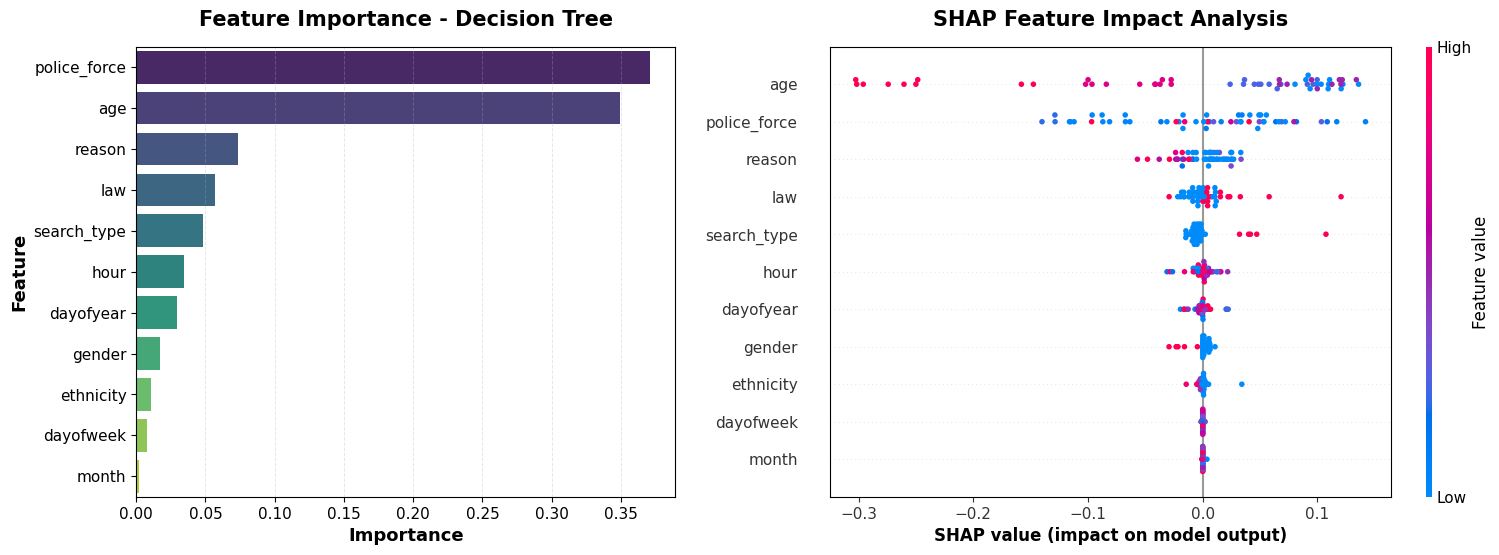

Test data size: 99775



Optimizing threshold based on 'min_recall_difference':
* Evaluating 16 thresholds from 0.5 to 1.0...
* Optimization metric: min_recall_difference


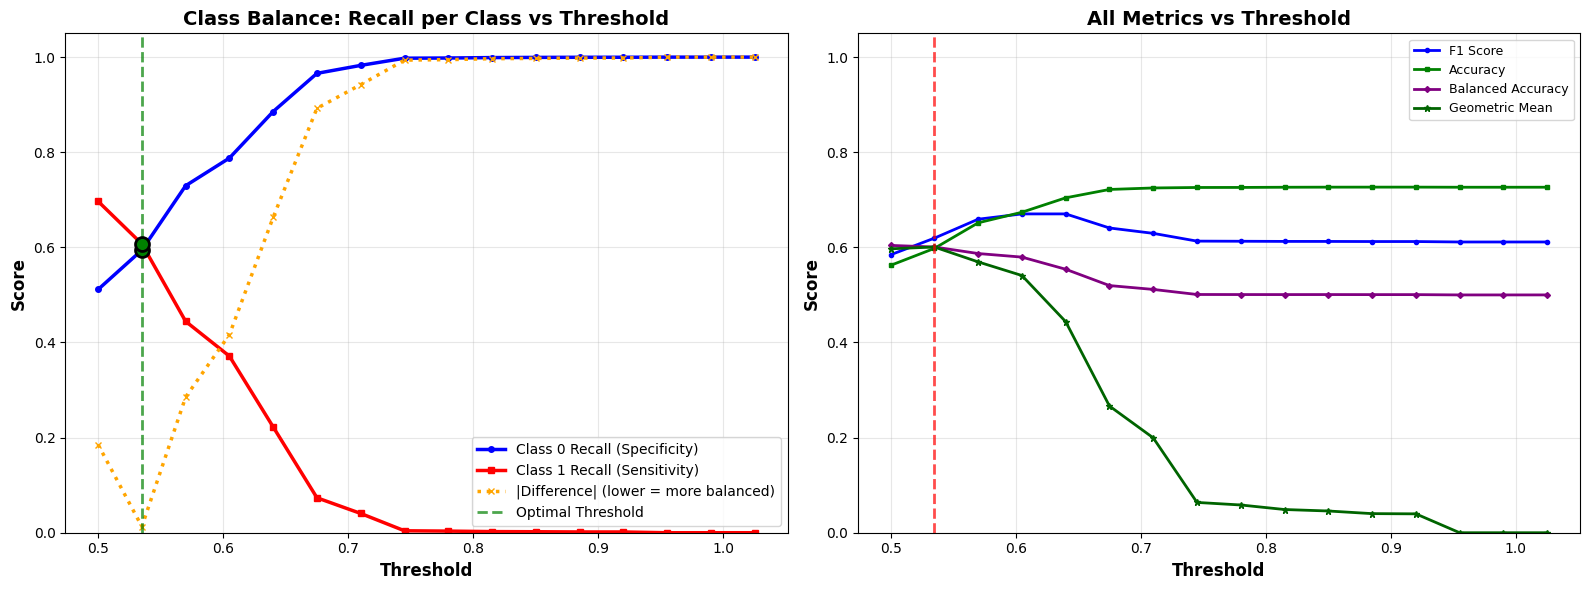


THRESHOLD OPTIMIZATION RESULTS
Optimization Metric: Recall Difference (minimized)
Optimal Threshold:   0.5350
Minimum Recall Difference: 0.0129

ALL METRICS AT OPTIMAL THRESHOLD:
  Accuracy:           0.5978
  Balanced Accuracy:  0.6008
  Geometric Mean:     0.6007
  F1 Score:           0.6194
  Precision: 0.6803
  Recall:    0.5978

  Class 0 Recall (Specificity): 0.5943
  Class 1 Recall (Sensitivity): 0.6072
  Recall Difference:            0.0129



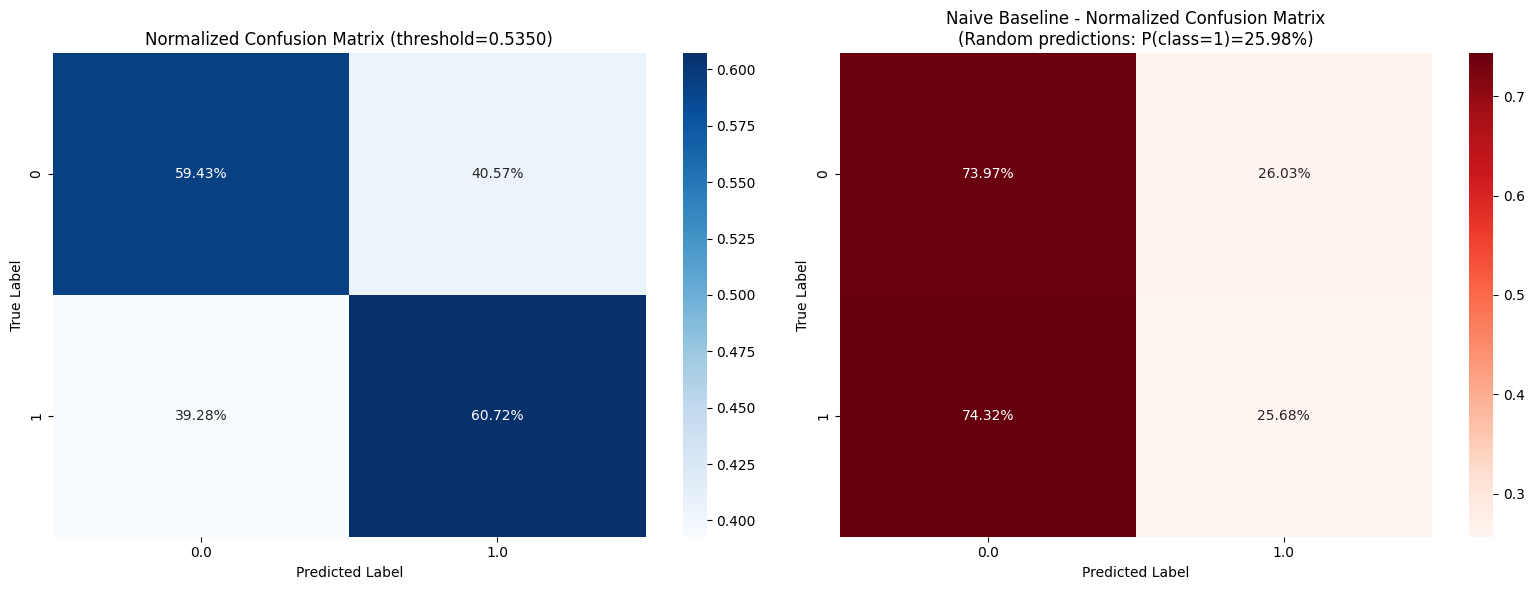


MODEL COMPARISON
Metric               Trained Model   Naive Baseline  Improvement    
------------------------------------------------------------
Accuracy             0.5978          0.6076          -0.0098        
Balanced Accuracy    0.6008          0.4983          0.1025         
Geometric Mean       0.6007          0.4358          0.1649         
F1 Score             0.6194          0.6043          0.0151         
Precision            0.6803          0.6011          0.0791         
Recall               0.5978          0.6076          -0.0098        
Class 0 Recall       0.5943          0.7397          -0.1454        
Class 1 Recall       0.6072          0.2568          0.3504         
Recall Difference    0.0129          0.4830          -0.4700        


 Unbalance: 260,824 (72.27%) negatives vs 100,100 (27.73%) positives

Starting Pipeline Training...


Pipeline fitting complete. Total time: 21.09 seconds.
Getting a set of 100 samples for the SHAP...


Calculating SHAP values...


  0%|          | 0/66 [00:00<?, ?it/s]

/home/alumno/py313ml/.venv/lib/python3.13/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


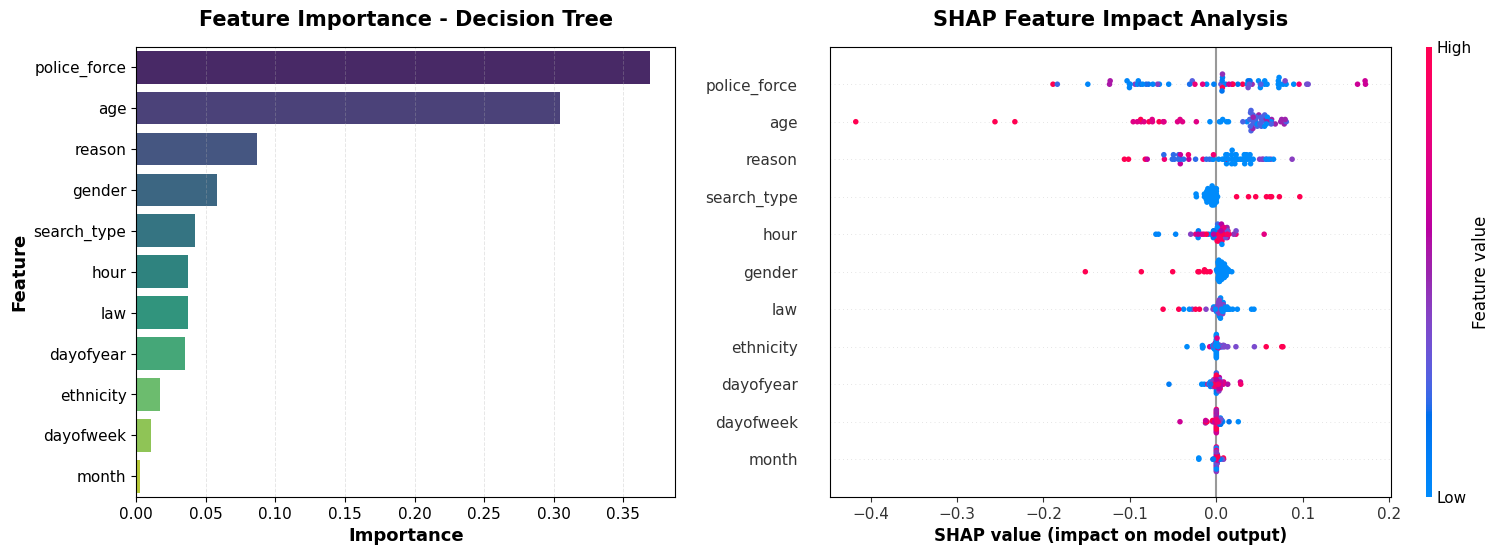

Test data size: 81323



Using provided threshold: 0.535


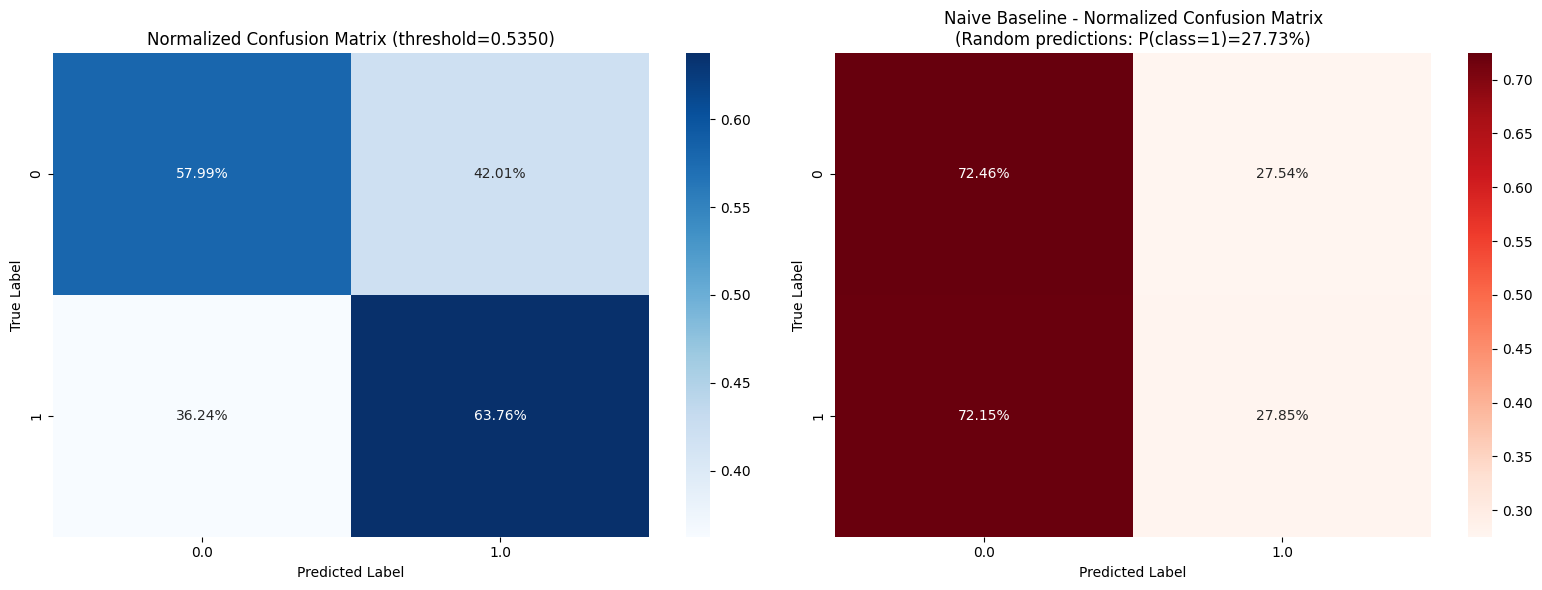


MODEL COMPARISON
Metric               Trained Model   Naive Baseline  Improvement    
------------------------------------------------------------
Accuracy             0.5965          0.5962          0.0004         
Balanced Accuracy    0.6088          0.5016          0.1072         
Geometric Mean       0.6081          0.4492          0.1589         
F1 Score             0.6156          0.5937          0.0219         
Precision            0.6780          0.5913          0.0867         
Recall               0.5965          0.5962          0.0004         
Class 0 Recall       0.5799          0.7246          -0.1447        
Class 1 Recall       0.6376          0.2785          0.3591         
Recall Difference    0.0577          0.4461          -0.3884        


 Unbalance: 229,787 (72.68%) negatives vs 86,369 (27.32%) positives

Starting Pipeline Training...


Pipeline fitting complete. Total time: 19.32 seconds.
Getting a set of 100 samples for the SHAP...


[Stage 27542:=========================================>             (3 + 1) / 4]

Calculating SHAP values...


  0%|          | 0/67 [00:00<?, ?it/s]

/home/alumno/py313ml/.venv/lib/python3.13/site-packages/shap/plots/_beeswarm.py:1150: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


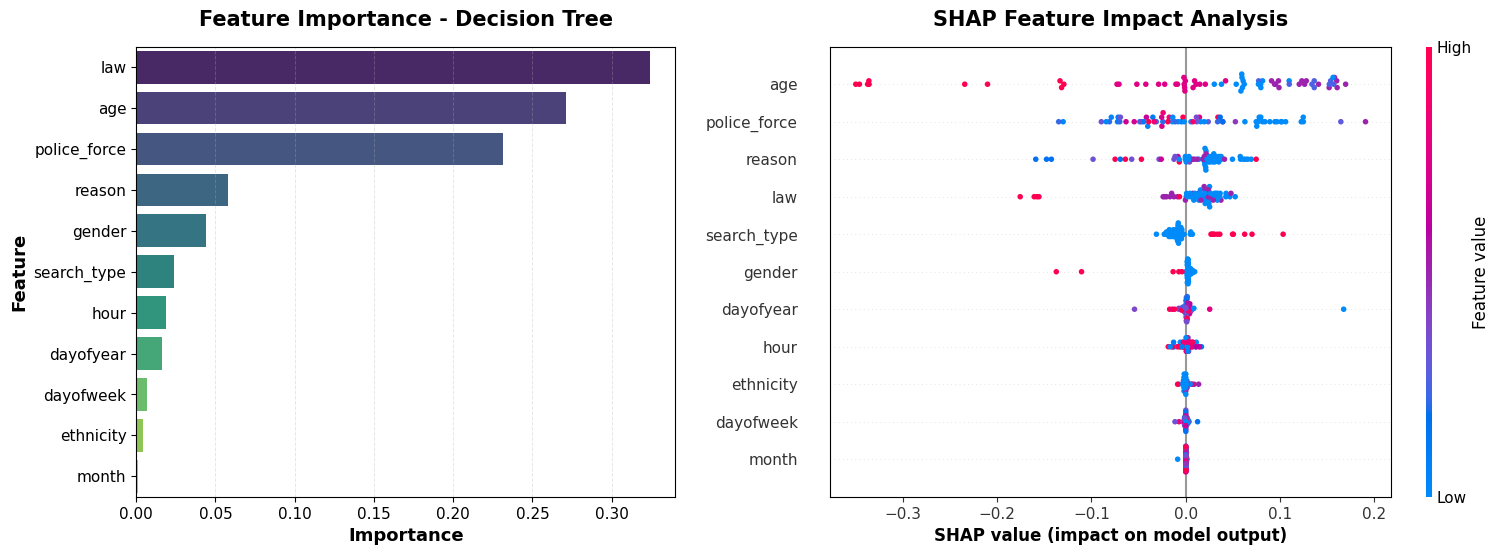

Test data size: 71148



Using provided threshold: 0.535


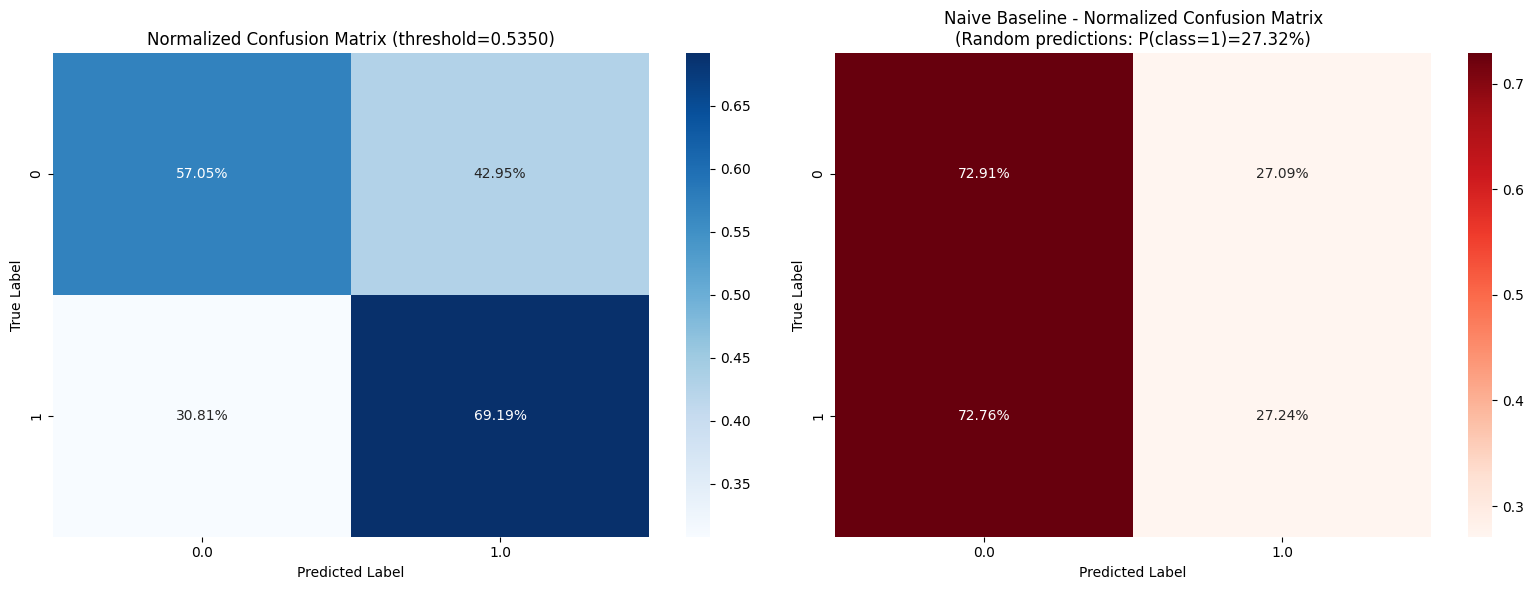


MODEL COMPARISON
Metric               Trained Model   Naive Baseline  Improvement    
------------------------------------------------------------
Accuracy             0.6049          0.5998          0.0052         
Balanced Accuracy    0.6312          0.5007          0.1305         
Geometric Mean       0.6283          0.4456          0.1827         
F1 Score             0.6244          0.5971          0.0272         
Precision            0.7010          0.5946          0.1063         
Recall               0.6049          0.5998          0.0052         
Class 0 Recall       0.5705          0.7291          -0.1585        
Class 1 Recall       0.6919          0.2724          0.4196         
Recall Difference    0.1214          0.4567          -0.3353        


In [90]:
fractions = {
    2022: 0.8,
    2023: 0.8,
    2024: 0.8,
    2025: 0.8
}

# Stratified sampling
train_df = df_final.sampleBy("year", fractions, seed=42)
test_df = df_final.join(train_df, on=df_final.columns, how="left_anti")

best_threshold = None
for year in [2023, 2024, 2025]:
    if year == 2023:
        train_df_objective = (
            train_df.filter(
                F.col("year") <= year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") <= year
            )
        )
    else:
        train_df_objective = (
            train_df.filter(
                F.col("year") == year
            )
        )
        
        test_df_objective = (
            test_df.filter(
                F.col("year") == year
            )
        )

    trained_pipeline, neg_count, pos_count, transformed_df = train_dt(
        train_df_objective,
        categorical_cols, 
        numeric_cols,
        feature_cols
    )
    
    show_importances(
        year=year,
        trained_pipeline=trained_pipeline,
        categorical_cols=categorical_cols,
        numeric_cols=numeric_cols,
        feature_cols=feature_cols,
        transformed_df=transformed_df,
        sample_size=100  
    )
    
    if best_threshold is None:
        predictions, best_threshold = calculate_metrics(
            year = year,
            trained_pipeline = trained_pipeline,
            test_df = test_df_objective,
            neg_count = neg_count,
            pos_count = pos_count,
            threshold = None,
            optimize_threshold=True,
            optimization_metric='min_recall_difference'
        )

    else:
        predictions, best_threshold = calculate_metrics(
            year = year,
            trained_pipeline = trained_pipeline,
            test_df = test_df_objective,
            neg_count = neg_count,
            pos_count = pos_count,
            threshold = best_threshold,
            optimize_threshold=False
        )

### 7.3 Conclusion

Despite training the Decision Tree model under carefully controlled conditions using consistent preprocessing, class weighting, and well-tuned hyperparameters, the resulting confusion matrices do not exhibit strong or well-balanced predictive performance. This suggests that the selected features do not have a sufficiently strong or systematic relationship with the target variable to reliably distinguish between outcomes. Consequently, within the scope of the variables and data analysed, we do not find clear evidence of systematic bias in UK police arrest decisions. 

Rather than indicating model failure, these results point to a limited explanatory signal in the available features, implying that any potential bias may be subtle, driven by unobserved factors, or not present in the dataset considered.